# Grupo N.º 2  
## Trabajo Grupal 3  
### Integrantes:
 - Héctor Ramos Vera 
 - David Sebastian Leon Guaman
 - Polk Brando Vernaza Quiñonez

### Análisis de Datos: Monitoreo de Pacientes en UCI y Predicción de Mortalidad (15 000 registros)
- El propósito de este conjunto de datos, centrado en el Análisis de Datos: Monitoreo de Pacientes en UCI y Predicción de Mortalidad, es proporcionar una base sólida para mejorar la toma de decisiones críticas en entornos hospitalarios mediante el uso de inteligencia de datos

### Instalación y configuración de Kaggle para la descarga del dataset

In [1]:
!pip install kaggle


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


- Descagar el dataset de de forma remota

In [2]:
!kaggle datasets download jayjoshi37/icu-patient-monitoring-and-mortality-prediction

Dataset URL: https://www.kaggle.com/datasets/jayjoshi37/icu-patient-monitoring-and-mortality-prediction
License(s): CC0-1.0
icu-patient-monitoring-and-mortality-prediction.zip: Skipping, found more recently modified local copy (use --force to force download)


## 1 Selección del dataset -
- Descromprimir el archivo zip

In [3]:
import zipfile
with zipfile.ZipFile("icu-patient-monitoring-and-mortality-prediction.zip", 'r') as zip_ref:
    zip_ref.extractall("icu_dataset")

- Importar las librerias 

In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline

- Instalación de la librería KaggleHub

In [5]:
!pip install kagglehub


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Importación de la librería KaggleHub

In [6]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

c:\Users\POLK\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


- Carga del dataset en un DataFrame

In [7]:
df=pd.read_csv('icu_dataset/ICU_Patient_Monitoring_Mortality_Prediction_15000.csv')

In [8]:
df

,patient_id,age,gender,admission_type,comorbidity_score,heart_rate_mean,heart_rate_std,heart_rate_max,heart_rate_min,systolic_bp_mean,...,glucose_mean,lactate_mean,urine_output_total,ventilation_required,vasopressor_used,length_of_stay_days,apache_score,sofa_score,sepsis_flag,mortality_label
0,PAT000001,32,Male,Urgent,3.75,136.06,19.64,162.01,127.16,104.04,...,73.71,7.77,4245.99,0,0,6.32,15.65,10.50,0,0
1,PAT000002,46,Male,Urgent,2.91,108.95,7.79,124.18,94.79,131.05,...,78.36,5.06,1267.36,0,1,29.00,33.29,6.09,0,1
2,PAT000003,87,Male,Urgent,6.84,95.21,7.44,117.54,89.35,171.84,...,168.41,1.89,4863.13,1,1,26.95,25.93,18.44,0,1
3,PAT000004,21,Male,Emergency,1.96,63.62,11.51,82.22,51.84,164.59,...,214.40,1.06,4940.99,1,0,1.16,33.54,14.14,0,1
4,PAT000005,21,Male,Urgent,7.71,65.92,12.17,74.98,39.34,146.10,...,201.33,5.28,4492.46,0,0,21.68,31.63,11.23,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,PAT014996,27,Female,Elective,0.02,100.21,15.97,105.34,79.25,123.65,...,217.13,3.22,1034.24,1,0,13.41,13.89,8.30,0,0
14996,PAT014997,68,Male,Emergency,8.39,88.72,13.34,100.69,77.45,148.53,...,171.81,5.17,989.13,0,1,14.36,38.71,1.03,0,0
14997,PAT014998,24,Female,Elective,9.06,83.32,23.45,109.28,56.80,133.29,...,201.38,2.23,3007.17,0,1,18.94,19.35,12.90,1,0
14998,PAT014999,82,Female,Emergency,3.60,86.64,23.59,95.87,67.42,137.37,...,203.62,2.99,1402.62,0,1,17.93,38.89,12.27,0,0


- Identificación de valores únicos en la variable de mortalidad

In [9]:
df['mortality_label'].unique()

array([0, 1])

- Distribución de la variable de mortalidad

In [10]:
df.groupby('mortality_label').size()

mortality_label
0    11582
1     3418
dtype: int64

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             15000 non-null  str    
 1   age                    15000 non-null  int64  
 2   gender                 15000 non-null  str    
 3   admission_type         15000 non-null  str    
 4   comorbidity_score      15000 non-null  float64
 5   heart_rate_mean        15000 non-null  float64
 6   heart_rate_std         15000 non-null  float64
 7   heart_rate_max         15000 non-null  float64
 8   heart_rate_min         15000 non-null  float64
 9   systolic_bp_mean       15000 non-null  float64
 10  systolic_bp_std        15000 non-null  float64
 11  respiratory_rate_mean  15000 non-null  float64
 12  spo2_mean              15000 non-null  float64
 13  temperature_mean       15000 non-null  float64
 14  glucose_mean           15000 non-null  float64
 15  lactate_mean 

### 2  Procesamiento de datos 
- Limpieza y Transformación de Datos


In [12]:
if df ['mortality_label'].dtype == 'object':
  le = LabelEncoder()
  df['mortality_label'] = le.fit_transform(df['mortality_label'])

  df = pd.get_dummies(df)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             15000 non-null  str    
 1   age                    15000 non-null  int64  
 2   gender                 15000 non-null  str    
 3   admission_type         15000 non-null  str    
 4   comorbidity_score      15000 non-null  float64
 5   heart_rate_mean        15000 non-null  float64
 6   heart_rate_std         15000 non-null  float64
 7   heart_rate_max         15000 non-null  float64
 8   heart_rate_min         15000 non-null  float64
 9   systolic_bp_mean       15000 non-null  float64
 10  systolic_bp_std        15000 non-null  float64
 11  respiratory_rate_mean  15000 non-null  float64
 12  spo2_mean              15000 non-null  float64
 13  temperature_mean       15000 non-null  float64
 14  glucose_mean           15000 non-null  float64
 15  lactate_mean 

- Detección y reporte de valores nulos

In [14]:
nulls   = df.isnull().sum()
null_pct = (nulls / len(df) * 100).round(2)
null_report = pd.DataFrame({'Nulos': nulls, 'Porcentaje (%)': null_pct})
null_report = null_report[null_report['Nulos'] > 0].sort_values('Porcentaje (%)', ascending=False)

print(f'Columnas con valores nulos: {len(null_report)} de {df.shape[1]}')
display(null_report if not null_report.empty else 'Sin valores nulos')

Columnas con valores nulos: 0 de 24


'Sin valores nulos'

- Separar columnas numéricas y categóricas 

In [15]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'\nColumnas numéricas  : {len(num_cols)}')
print(f'Columnas categóricas: {len(cat_cols)}')

if num_cols:
    imp_num = SimpleImputer(strategy='median')
    df[num_cols] = imp_num.fit_transform(df[num_cols])

if cat_cols:
    imp_cat = SimpleImputer(strategy='most_frequent')
    df[cat_cols] = imp_cat.fit_transform(df[cat_cols])

print('\n Imputación completada (mediana para numéricas, moda para categóricas).')

C:\Users\POLK\AppData\Local\Temp\ipykernel_16816\4246366318.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()



Columnas numéricas  : 21
Columnas categóricas: 3

 Imputación completada (mediana para numéricas, moda para categóricas).


- Eliminar duplicados

In [16]:
n_before = len(df)
df.drop_duplicates(inplace=True)
print(f' Duplicados eliminados: {n_before - len(df)}')

 Duplicados eliminados: 0


- Identificación de valores atípicos usando el rango intercuartílico (IQR)

In [17]:
outlier_report = {}
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    if n_out > 0:
        outlier_report[col] = n_out

outlier_df = pd.DataFrame.from_dict(outlier_report, orient='index', columns=['Outliers (IQR)'])
print(f'\nColumnas con outliers detectados: {len(outlier_df)}')
display(outlier_df.sort_values('Outliers (IQR)', ascending=False).head(10))


Columnas con outliers detectados: 3


,Outliers (IQR)
vasopressor_used,3677
mortality_label,3418
sepsis_flag,3029


- Detección automática de la columna objetivo (mortalidad)

In [18]:
TARGET_CANDIDATES = [
    'mortality', 'death', 'survived', 'outcome', 'hospital_death',
    'in_hospital_death', 'mortality_flag', 'deceased'
]
target_col = None
for c in df.columns:
    if c.lower().replace(' ', '_') in TARGET_CANDIDATES:
        target_col = c
        break

- primera columna binaria encontrada al final del df

In [19]:
if target_col is None:
    for c in reversed(df.columns):
        if df[c].nunique() == 2:
            target_col = c
            break

if target_col:
    print(f'\n Columna objetivo detectada: "{target_col}"')
    print(df[target_col].value_counts().rename_axis('Clase').reset_index(name='Conteo').to_string(index=False))
else:
    print('\n No se detectó columna objetivo binaria. Ajusta target_col manualmente.')


 Columna objetivo detectada: "mortality_label"
 Clase  Conteo
   0.0   11582
   1.0    3418


- Codificación de categóricas para ML

In [20]:
df_ml = df.copy()
le    = LabelEncoder()
for col in cat_cols:
    if col != target_col:
        df_ml[col] = le.fit_transform(df_ml[col].astype(str))

print(f'\n✔ Limpieza y transformación completadas. Shape final: {df.shape}')


✔ Limpieza y transformación completadas. Shape final: (15000, 24)


## 4. Análisis Exploratorio de Datos (EDA) </a>

El EDA responde tres preguntas clave:

1. **¿Cómo se distribuye la mortalidad?** → Tasa global y balance de clases.
2. **¿Qué variables numéricas difieren más entre pacientes que sobrevivieron y los que fallecieron?** → Análisis de medias por grupo.
3. **¿Qué variables están más correlacionadas con la mortalidad?** → Top correlaciones.

Estos hallazgos guiarán tanto las visualizaciones como la selección de features para el modelo.

- Tasa de mortalidad global

In [21]:
if target_col:
    mortality_rate = df[target_col].mean() * 100
    print(f'Tasa de mortalidad global : {mortality_rate:.2f}%')
    print(f'Pacientes totales         : {len(df):,}')
    print(f'Fallecidos                : {int(df[target_col].sum()):,}')
    print(f'Sobrevivientes            : {int((df[target_col] == 0).sum()):,}')

Tasa de mortalidad global : 22.79%
Pacientes totales         : 15,000
Fallecidos                : 3,418
Sobrevivientes            : 11,582


- Estadísticas por grupo (fallecido vs sobreviviente)

In [22]:
if target_col:
    print('\n── Medias por grupo (Fallecido=1 vs Sobreviviente=0) ──')
    group_stats = df.groupby(target_col)[num_cols].mean().round(3).T
    group_stats.columns = ['Sobrevivió (0)', 'Falleció (1)']
    group_stats['Diferencia %'] = (
        (group_stats['Falleció (1)'] - group_stats['Sobrevivió (0)'])
        / group_stats['Sobrevivió (0)'].replace(0, np.nan) * 100
    ).round(1)
    display(group_stats.sort_values('Diferencia %', key=abs, ascending=False).head(15))


── Medias por grupo (Fallecido=1 vs Sobreviviente=0) ──


,Sobrevivió (0),Falleció (1),Diferencia %
vasopressor_used,0.221,0.328,48.4
sepsis_flag,0.182,0.270,48.4
ventilation_required,0.274,0.398,45.3
comorbidity_score,4.889,5.328,9.0
sofa_score,9.785,10.650,8.8
apache_score,22.139,23.709,7.1
age,53.317,56.260,5.5
systolic_bp_mean,135.016,133.982,-0.8
length_of_stay_days,15.456,15.353,-0.7
glucose_mean,158.910,159.811,0.6


- Top correlaciones con la variable objetivo 

In [23]:
if target_col and target_col in num_cols:
    correlaciones = df[num_cols].corr()[target_col].drop(target_col)
    top_corr = correlaciones.abs().sort_values(ascending=False).head(12)
    print('\n── Top 12 variables más correlacionadas con la mortalidad ──')
    corr_df = pd.DataFrame({
        'Variable': top_corr.index,
        'Correlación (|r|)': top_corr.values,
        'Dirección': ['Positiva' if correlaciones[v] > 0 else 'Negativa' for v in top_corr.index]
    })
    display(corr_df)


── Top 12 variables más correlacionadas con la mortalidad ──


,Variable,Correlación (|r|),Dirección
0,ventilation_required,0.113897,Positiva
1,vasopressor_used,0.104242,Positiva
2,sepsis_flag,0.092561,Positiva
3,apache_score,0.065262,Positiva
4,comorbidity_score,0.063640,Positiva
5,sofa_score,0.063130,Positiva
6,age,0.058697,Positiva
7,systolic_bp_mean,0.016689,Negativa
8,respiratory_rate_mean,0.008570,Negativa
9,systolic_bp_std,0.007903,Positiva


- Instalar libreria seaborn y matplotlib

In [24]:
!pip install seaborn matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


- Importar librerias

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import random
import os

## 5 Visualización de Datos
- Gráficos estáticos (matplotlib / seaborn)

C:\Users\POLK\AppData\Local\Temp\ipykernel_16816\1273054090.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette=['#2ecc71', '#e74c3c'], ax=axes[0])


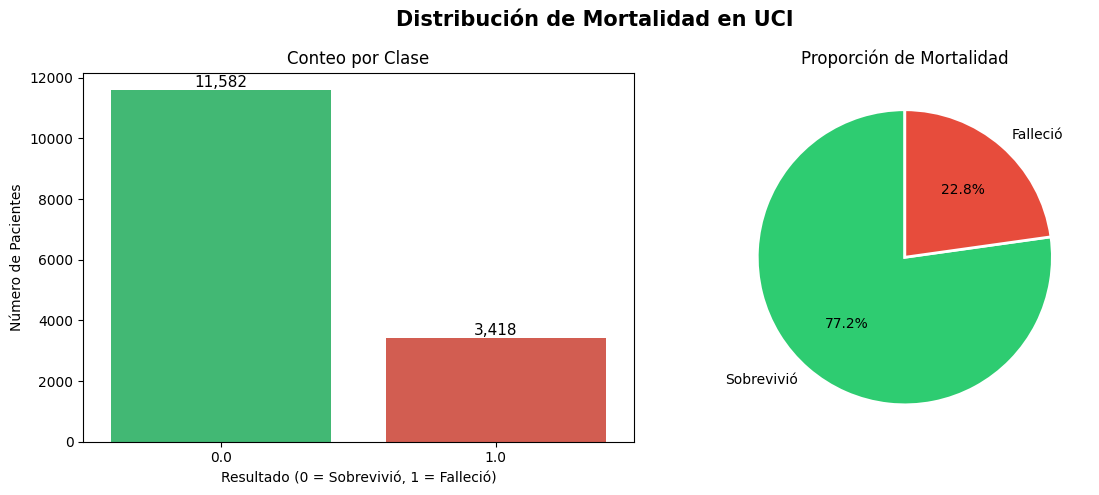

 Gráfico 1 guardado en la carpeta: graficos


In [26]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

OUT_STATIC = "graficos"  
os.makedirs(OUT_STATIC, exist_ok=True)  

if target_col:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Distribución de Mortalidad en UCI', fontsize=15, fontweight='bold')

    counts = df[target_col].value_counts().sort_index()
    labels = ['Sobrevivió', 'Falleció']

    sns.countplot(x=target_col, data=df, palette=['#2ecc71', '#e74c3c'], ax=axes[0])
    axes[0].set_title('Conteo por Clase')
    axes[0].set_xlabel('Resultado (0 = Sobrevivió, 1 = Falleció)')
    axes[0].set_ylabel('Número de Pacientes')
    for p in axes[0].patches:
        axes[0].annotate(f'{int(p.get_height()):,}',
                         (p.get_x() + p.get_width()/2., p.get_height()),
                         ha='center', va='bottom', fontsize=11)

    
    axes[1].pie(counts.values, labels=labels,
                colors=['#2ecc71', '#e74c3c'],
                autopct='%1.1f%%', startangle=90,
                wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    axes[1].set_title('Proporción de Mortalidad')

    plt.tight_layout()
    
    plt.savefig(os.path.join(OUT_STATIC, '01_distribucion_mortalidad.png'), bbox_inches='tight')
    plt.show()
    print(' Gráfico 1 guardado en la carpeta:', OUT_STATIC)

- Distribuciones de variables numéricas clave

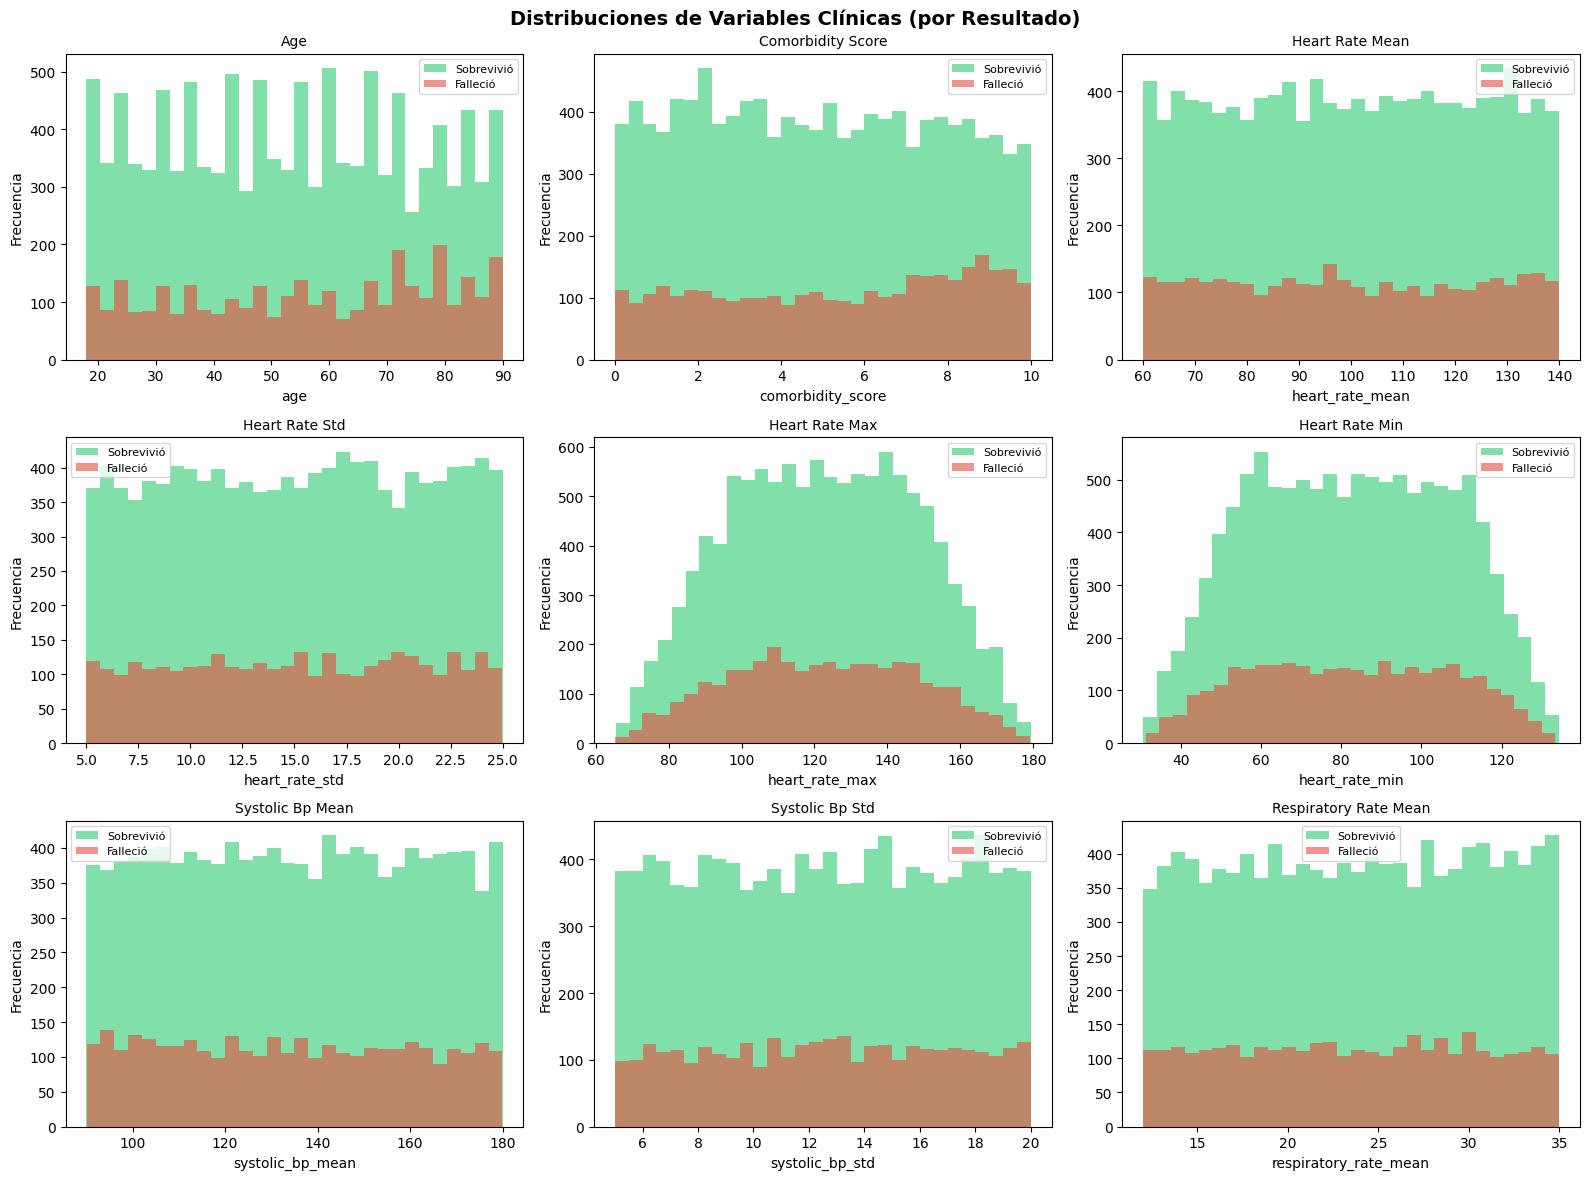

 Gráfico 2 guardado.


In [27]:
plot_cols = [c for c in num_cols if c != target_col][:9]

if plot_cols:
    n = len(plot_cols)
    cols_g = 3
    rows_g = (n + cols_g - 1) // cols_g
    fig, axes = plt.subplots(rows_g, cols_g, figsize=(16, rows_g * 4))
    axes = axes.flatten()
    fig.suptitle('Distribuciones de Variables Clínicas (por Resultado)', fontsize=14, fontweight='bold')

    for i, col in enumerate(plot_cols):
        ax = axes[i]
        if target_col:
            for val, color, lbl in zip([0, 1], ['#2ecc71', '#e74c3c'], ['Sobrevivió', 'Falleció']):
                subset = df[df[target_col] == val][col].dropna()
                ax.hist(subset, bins=30, alpha=0.6, color=color, label=lbl, edgecolor='none')
            ax.legend(fontsize=8)
        else:
            ax.hist(df[col].dropna(), bins=30, color='#3498db', alpha=0.8, edgecolor='none')
        ax.set_title(col.replace('_', ' ').title(), fontsize=10)
        ax.set_xlabel(col)
        ax.set_ylabel('Frecuencia')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'{OUT_STATIC}/02_distribuciones_variables.png', bbox_inches='tight')
    plt.show()
    print(' Gráfico 2 guardado.')

- Mapa de calor de correlaciones

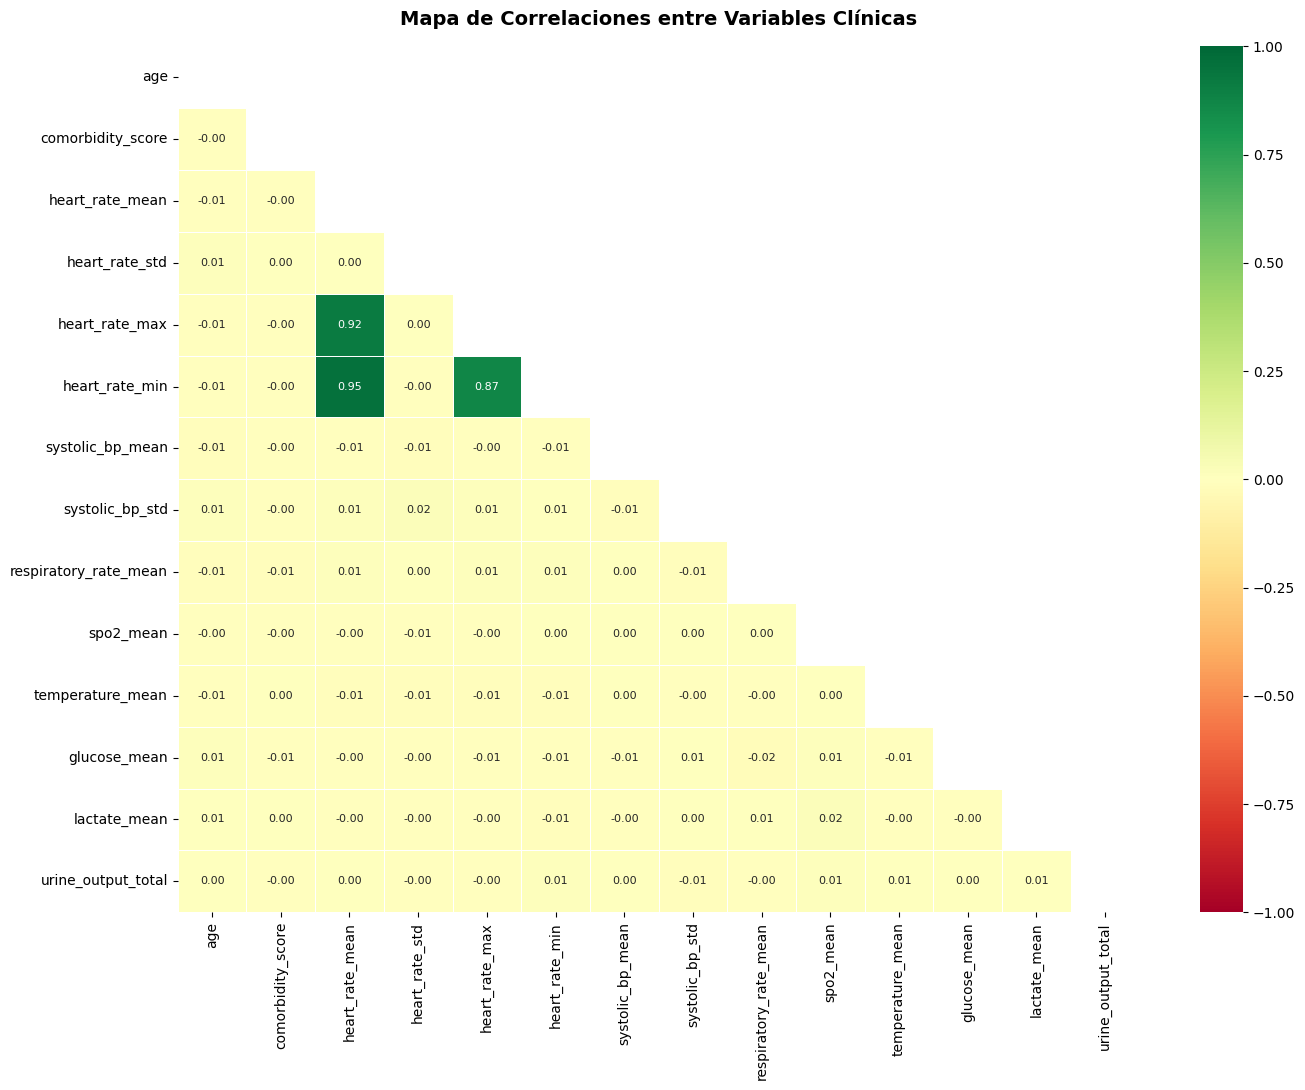

 Gráfico 3 guardado.


In [28]:
corr_cols = [c for c in num_cols][:14]

if len(corr_cols) >= 2:
    corr_matrix = df[corr_cols].corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    fig, ax = plt.subplots(figsize=(14, 11))
    sns.heatmap(
        corr_matrix, mask=mask, annot=True, fmt='.2f', linewidths=0.5,
        cmap='RdYlGn', center=0, vmin=-1, vmax=1,
        annot_kws={'size': 8}, ax=ax
    )
    ax.set_title('Mapa de Correlaciones entre Variables Clínicas', fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig(f'{OUT_STATIC}/03_correlaciones_heatmap.png', bbox_inches='tight')
    plt.show()
    print(' Gráfico 3 guardado.')

- Boxplots por clase  

C:\Users\POLK\AppData\Local\Temp\ipykernel_16816\2159125258.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\POLK\AppData\Local\Temp\ipykernel_16816\2159125258.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\POLK\AppData\Local\Temp\ipykernel_16816\2159125258.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\POLK\AppData\Local\Temp\ipykernel_16816\2159125258.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

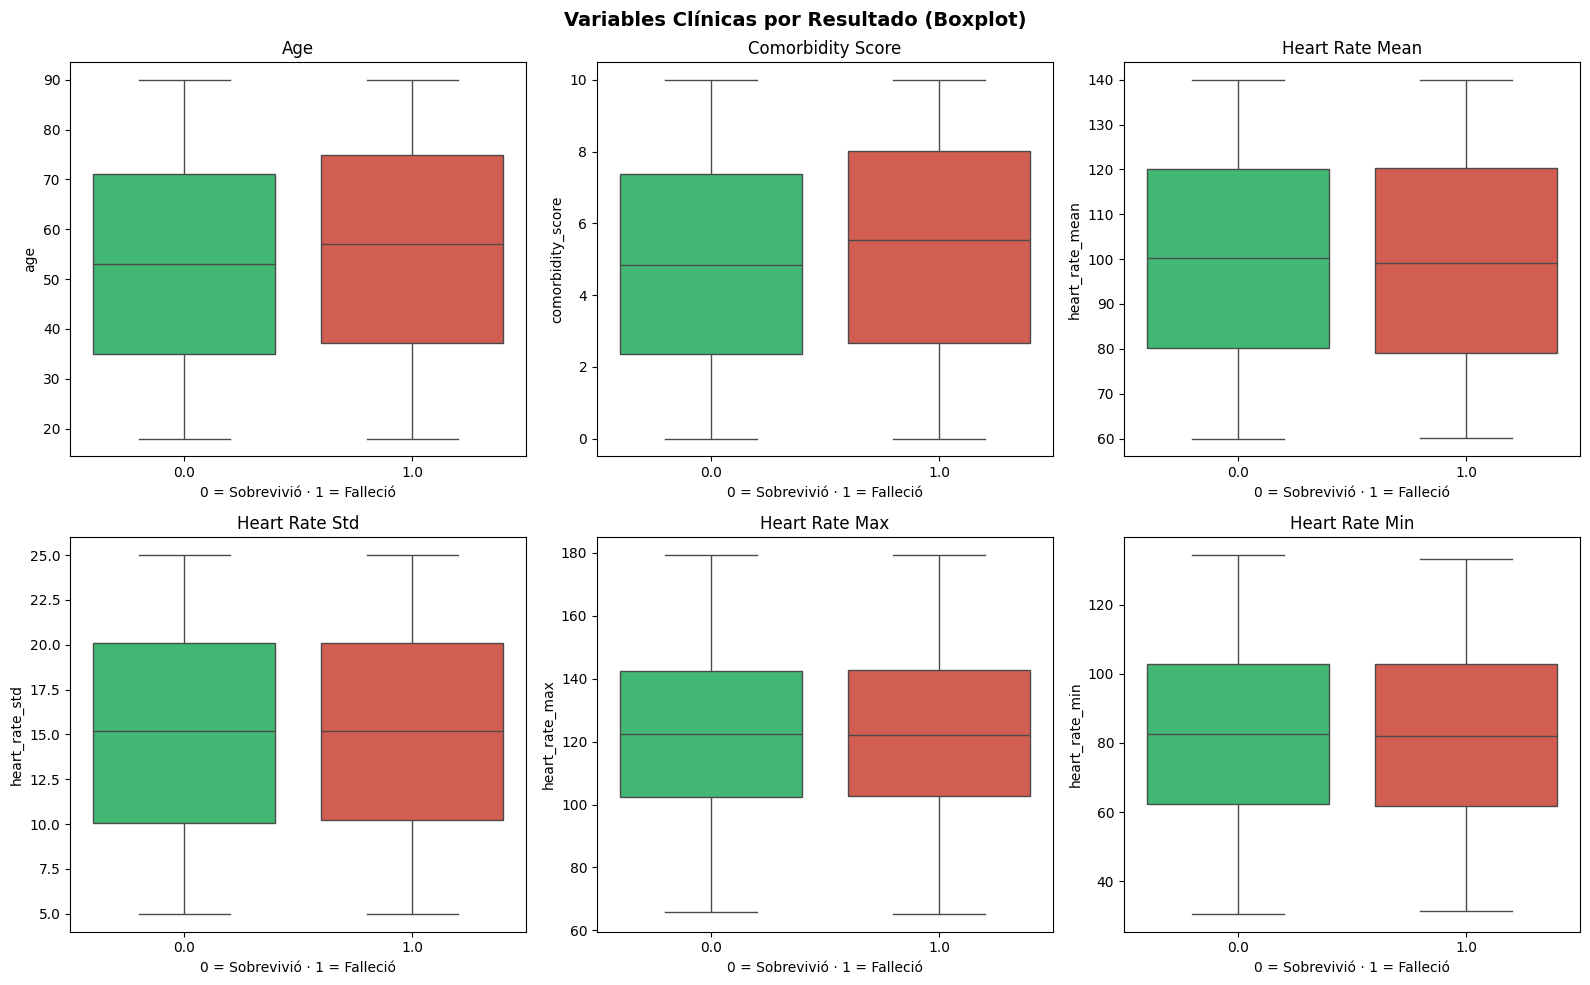

 Gráfico 4 guardado.


In [29]:
if target_col:
    box_cols = [c for c in num_cols if c != target_col][:6]
    if box_cols:
        fig, axes = plt.subplots(2, 3, figsize=(16, 10))
        axes = axes.flatten()
        fig.suptitle('Variables Clínicas por Resultado (Boxplot)', fontsize=14, fontweight='bold')

        for i, col in enumerate(box_cols):
            sns.boxplot(
                x=target_col, y=col, data=df,
                palette=['#2ecc71', '#e74c3c'],
                flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.3},
                ax=axes[i]
            )
            axes[i].set_title(col.replace('_', ' ').title())
            axes[i].set_xlabel('0 = Sobrevivió · 1 = Falleció')

        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)

        plt.tight_layout()
        plt.savefig(f'{OUT_STATIC}/04_boxplots_por_clase.png', bbox_inches='tight')
        plt.show()
        print(' Gráfico 4 guardado.')

- Variables categóricas vs mortalidad 

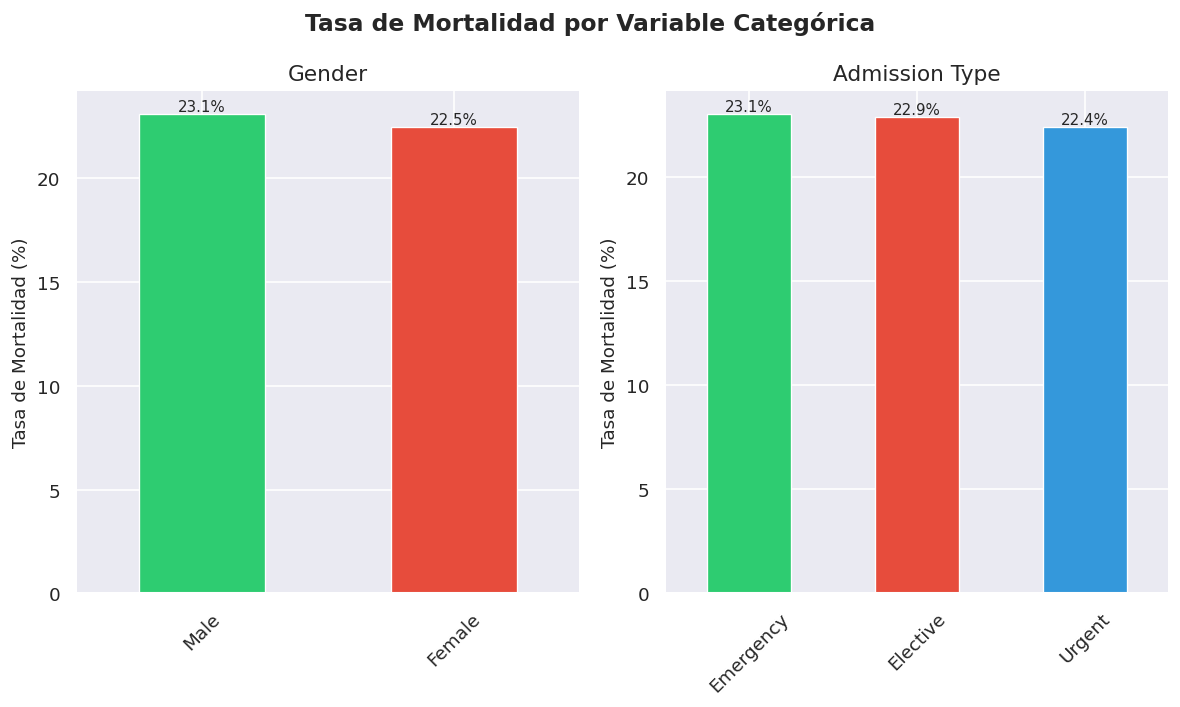

 Gráfico 5 guardado.


In [30]:
# Paleta de colores consistente en todo el notebook
PALETTE = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6', '#1abc9c']
sns.set_theme(style='darkgrid', palette=PALETTE)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans'
})

cat_to_plot = [c for c in cat_cols if c != target_col and df[c].nunique() <= 10][:4]

if cat_to_plot and target_col:
    n = len(cat_to_plot)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 6))
    if n == 1:
        axes = [axes]
    fig.suptitle('Tasa de Mortalidad por Variable Categórica', fontsize=14, fontweight='bold')

    for i, col in enumerate(cat_to_plot):
        mortality_by_cat = df.groupby(col)[target_col].mean().sort_values(ascending=False) * 100
        mortality_by_cat.plot(kind='bar', ax=axes[i],
                               color=PALETTE[:len(mortality_by_cat)],
                               edgecolor='white', linewidth=0.8)
        axes[i].set_title(col.replace('_', ' ').title())
        axes[i].set_ylabel('Tasa de Mortalidad (%)')
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=45)
        for bar in axes[i].patches:
            axes[i].annotate(f"{bar.get_height():.1f}%",
                             (bar.get_x() + bar.get_width()/2., bar.get_height()),
                             ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig(f'{OUT_STATIC}/05_mortalidad_por_categoria.png', bbox_inches='tight')
    plt.show()
    print(' Gráfico 5 guardado.')
else:
    print('(No hay variables categóricas con ≤10 categorías para graficar.)')

###  Selección aleatoria de registros
Esta instrucción realiza una selección aleatoria de índices dentro de un conjunto de datos almacenado en un *DataFrame*. Para ello utiliza la función sample del módulo random de la biblioteca estándar de Python.

In [31]:
indices = random.sample(range(len(df)), 5000)

In [32]:
df = df.sample(10000)

### Visualización de correlaciones en pacientes con mortalidad
 Este procedimiento genera una visualización de correlación entre variables del conjunto de datos utilizando herramientas de visualización de las bibliotecas Matplotlib y Seaborn. El objetivo es identificar relaciones estadísticas entre las variables en los registros asociados a mortalidad, permitiendo analizar posibles patrones clínicos o fisiológicos relevantes.

c:\Users\POLK\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
c:\Users\POLK\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


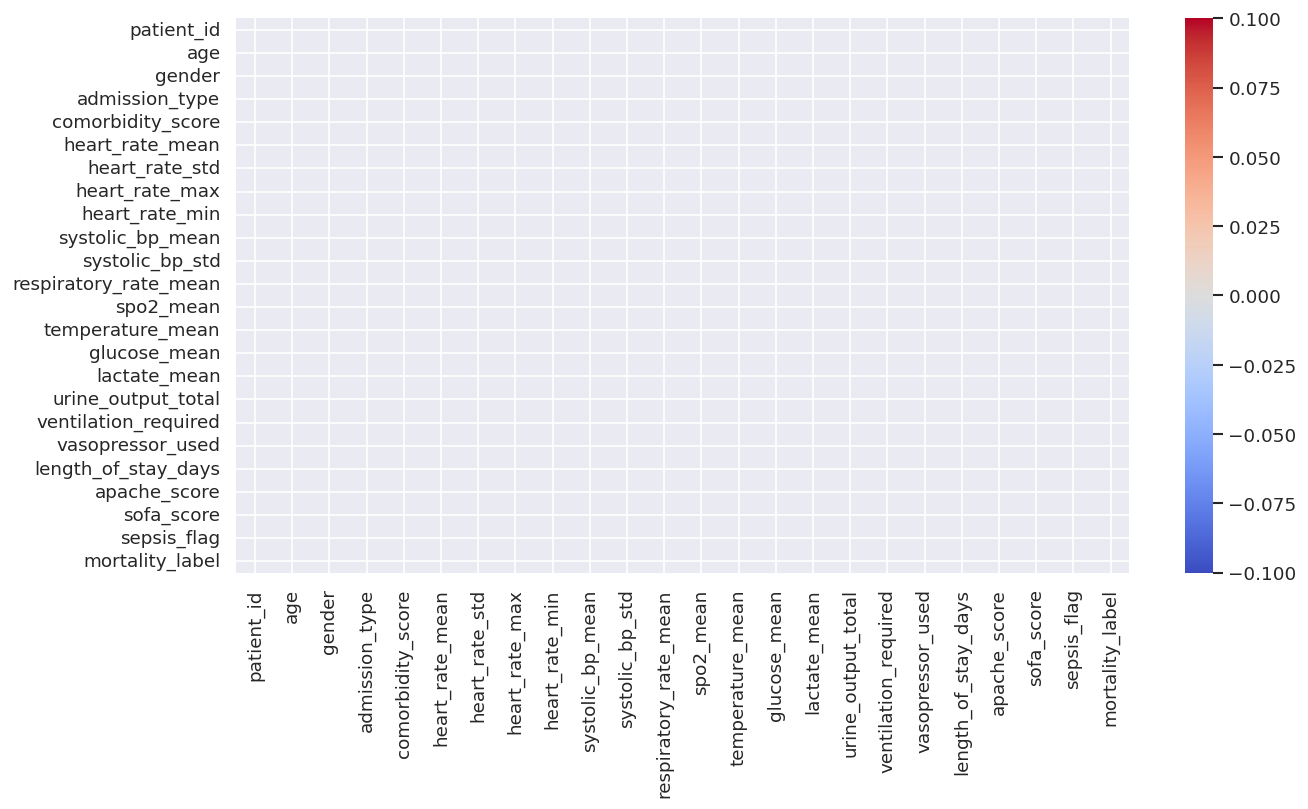

In [33]:
plt.figure(figsize=(12, 6))
sns.heatmap(df[df['respiratory_rate_mean'] == 1].corr(), cmap='coolwarm')
plt.show()

### Visualización comparativa de variables fisiológicas
Este procedimiento recorre todas las columnas del conjunto de datos para identificar aquellas variables que contienen la palabra "mean", las cuales generalmente representan valores promedio de variables clínicas o fisiológicas registradas en los pacientes.

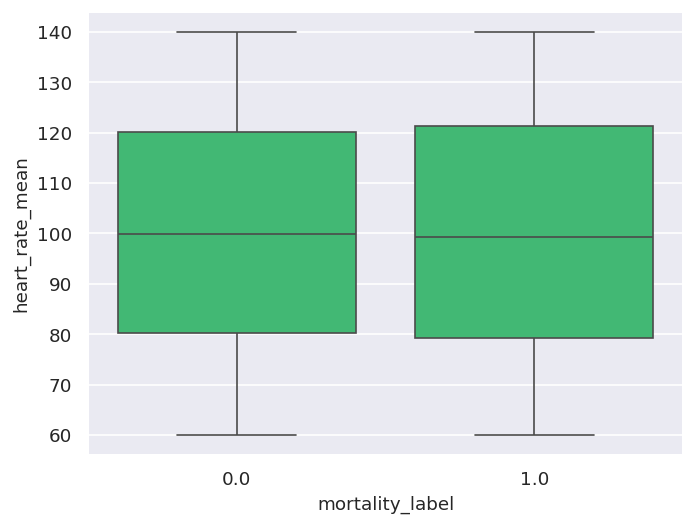

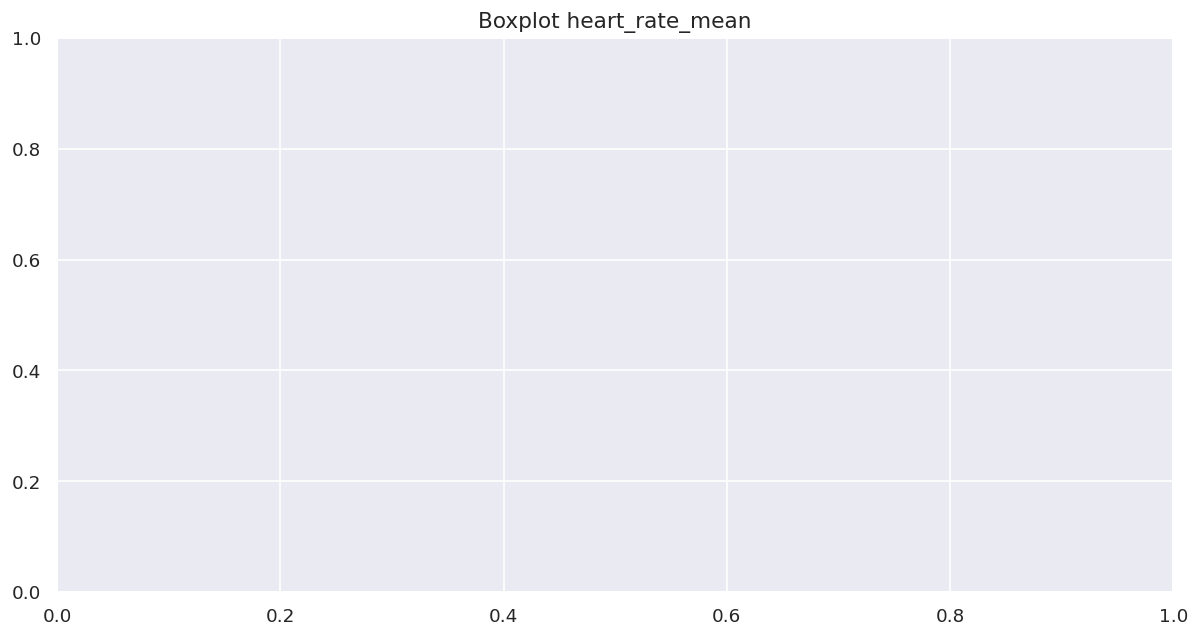

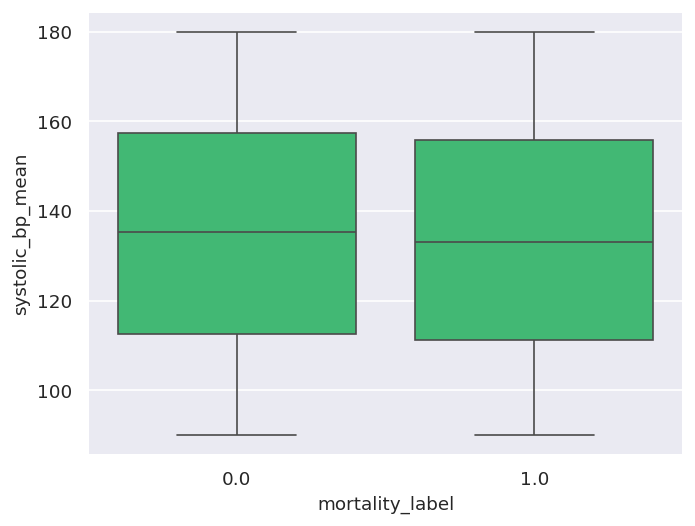

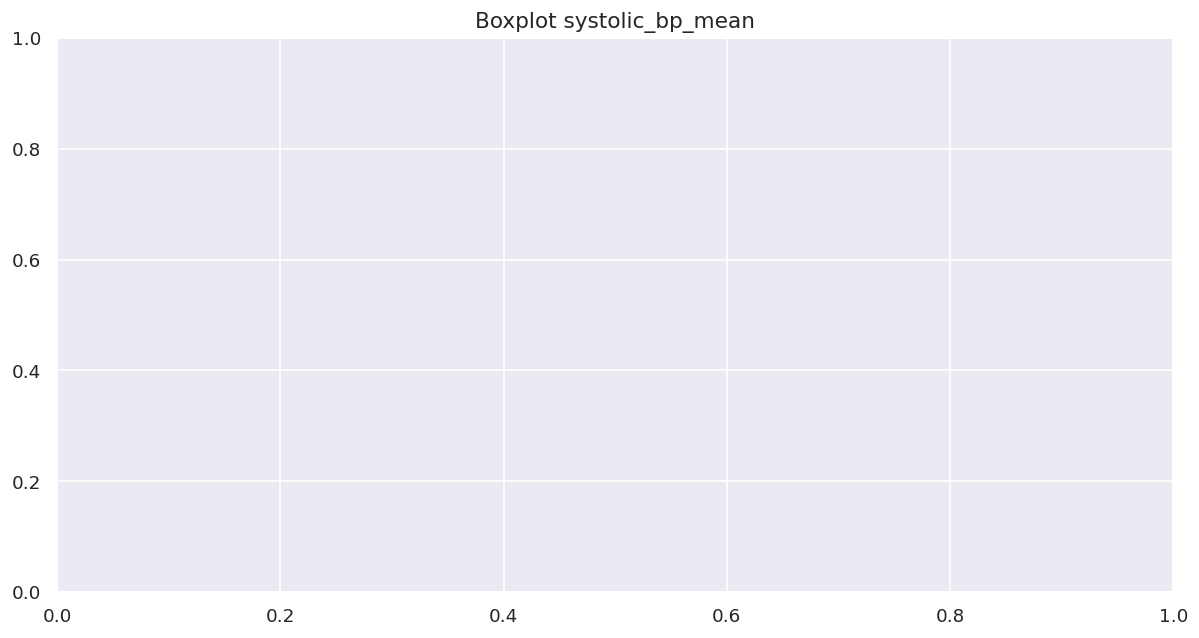

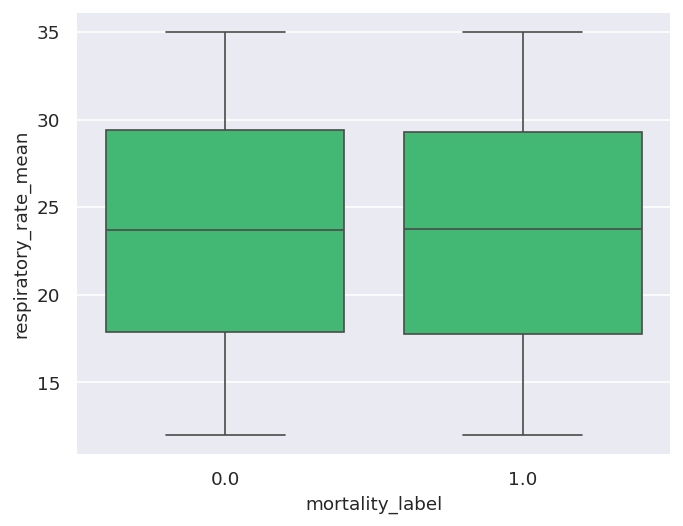

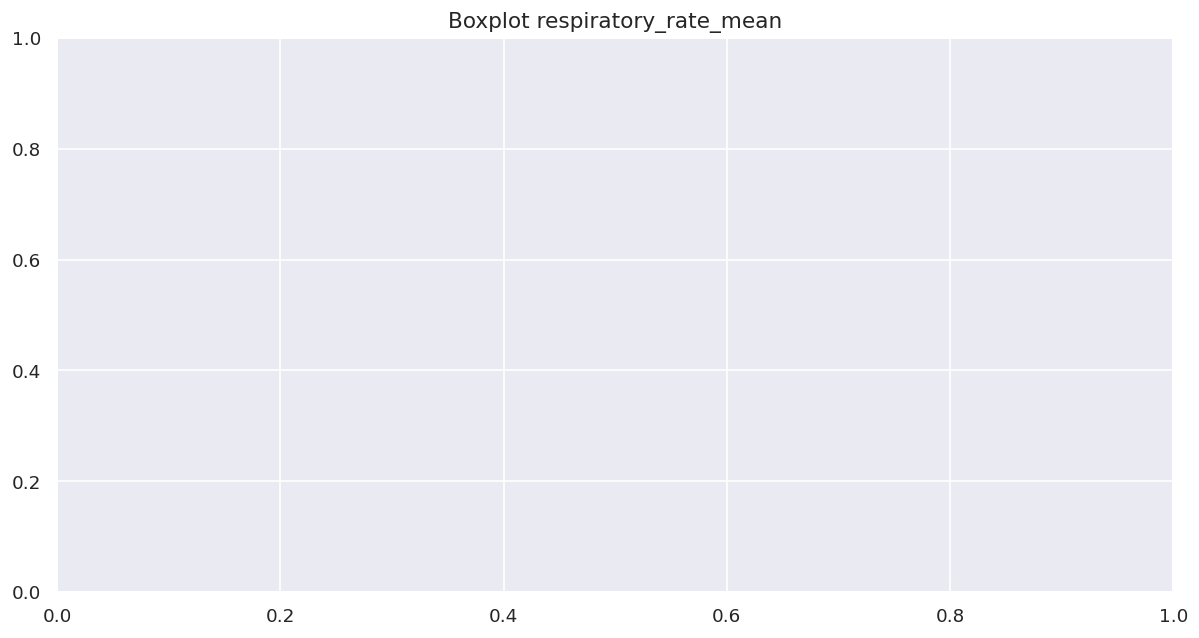

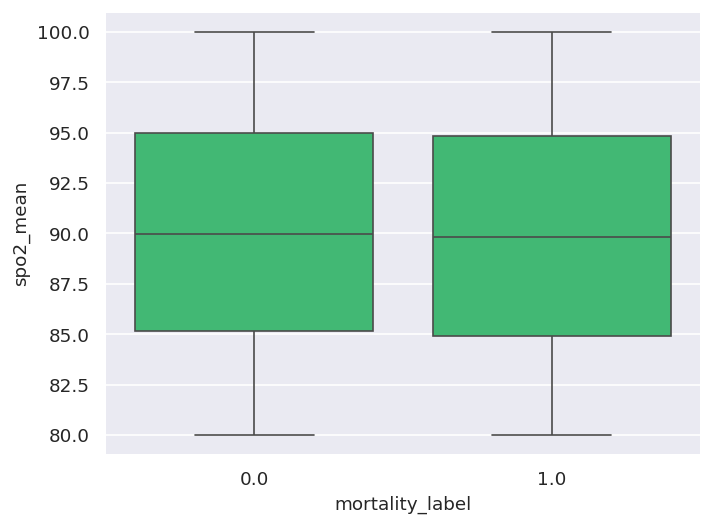

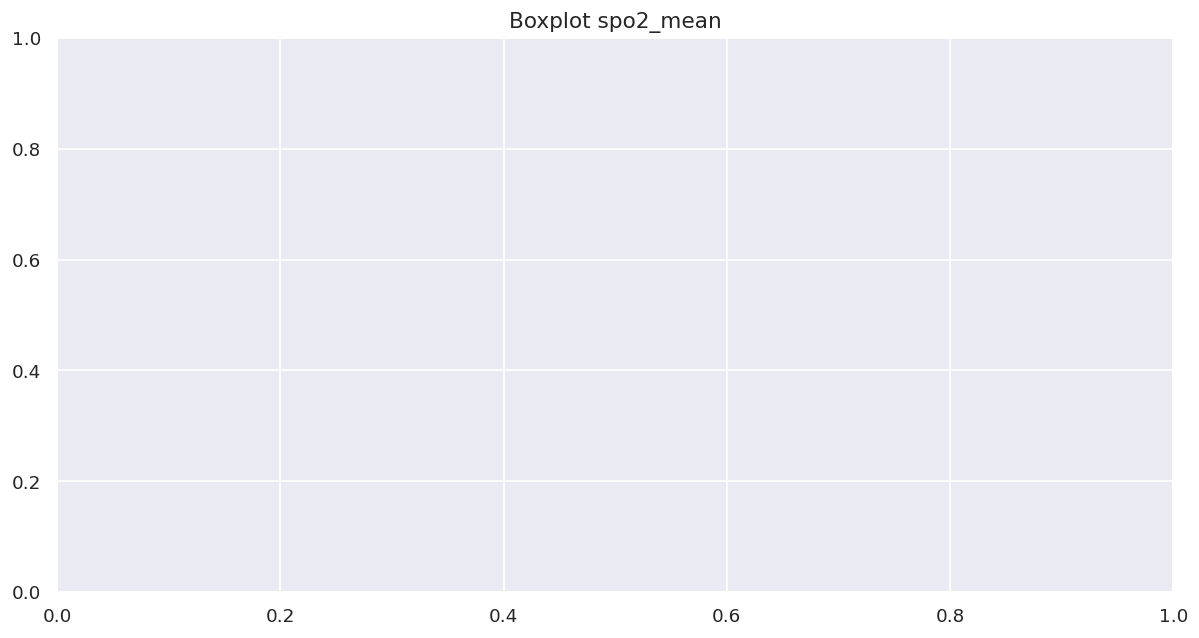

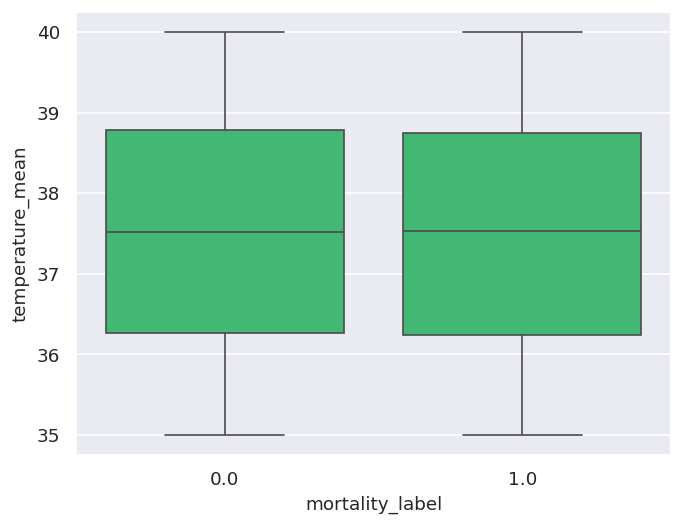

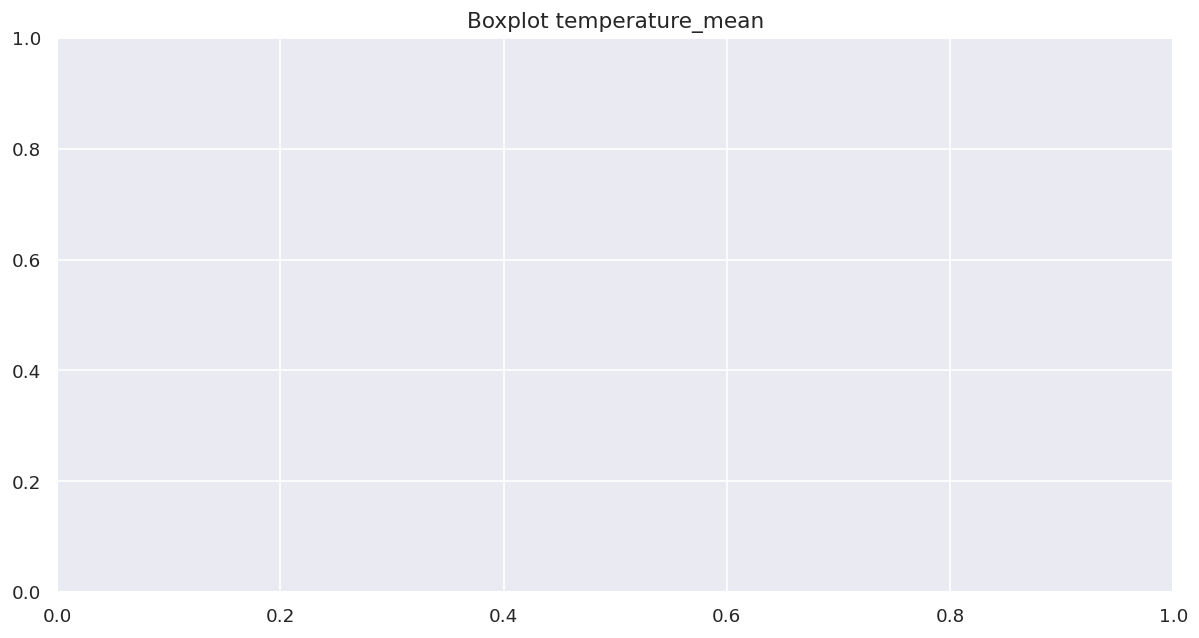

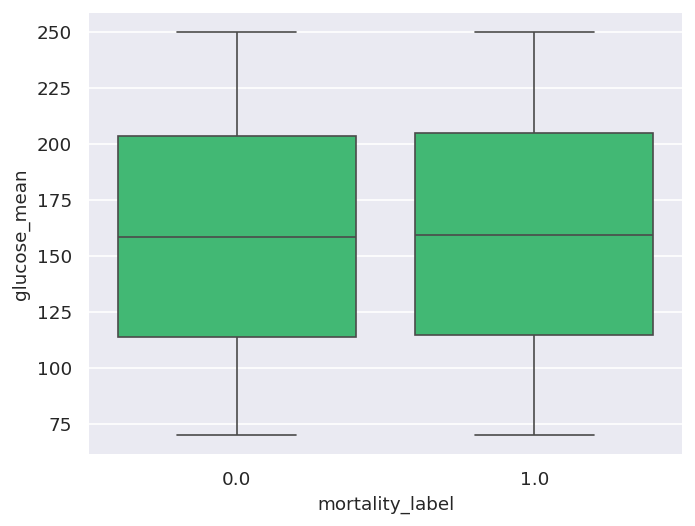

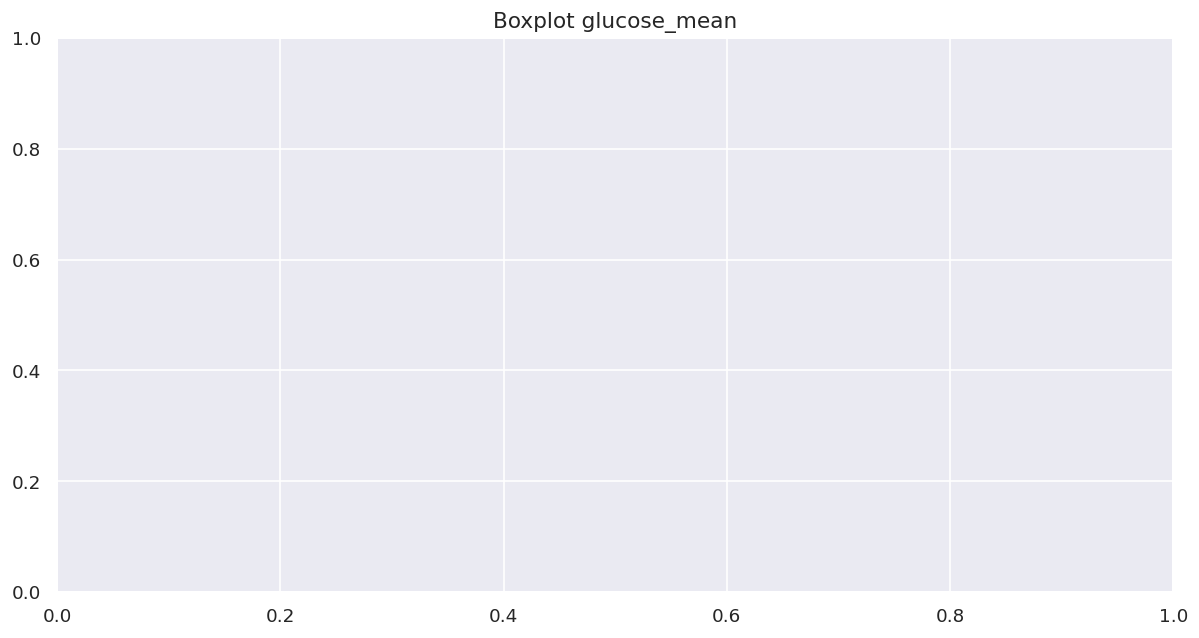

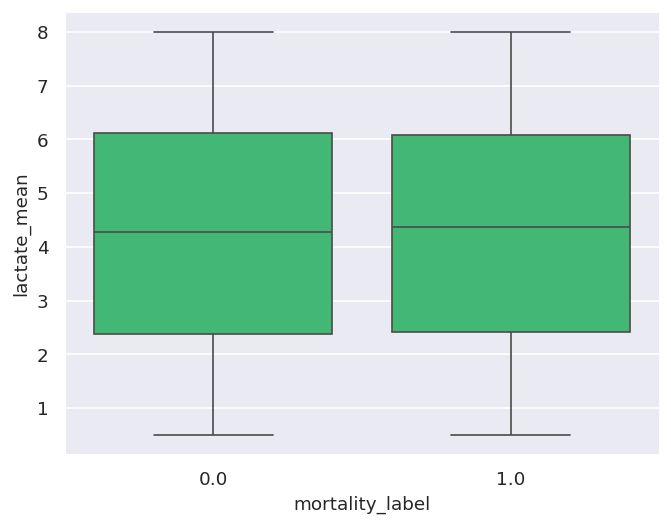

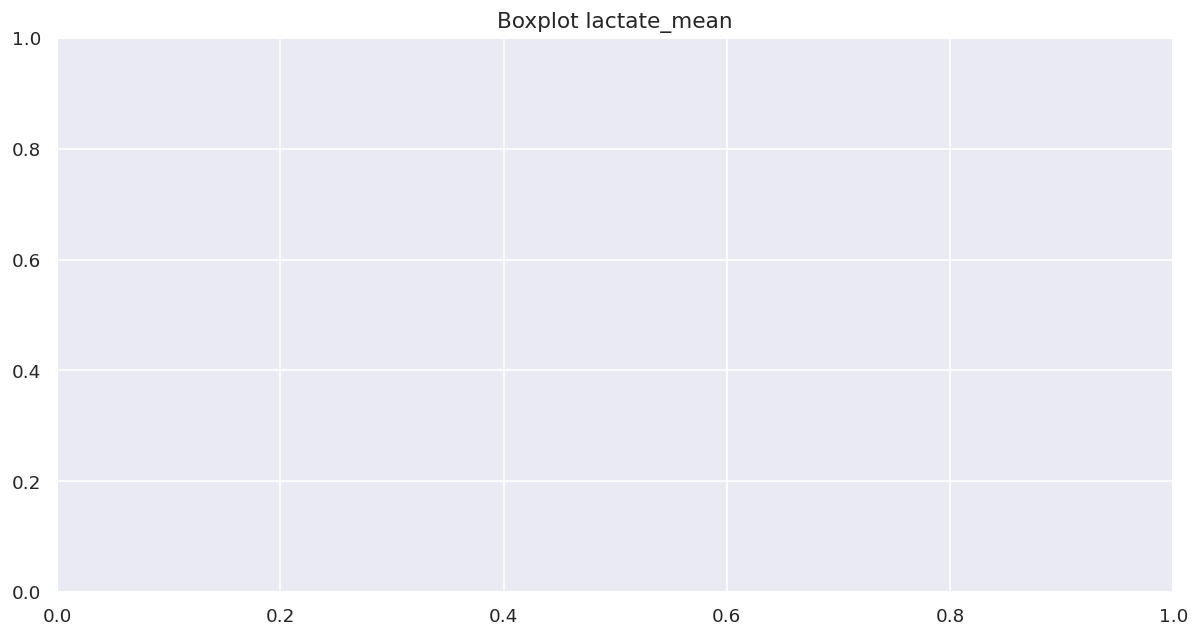

In [34]:
for col in df.columns:
  if 'mean' in str(col):
    sns.boxplot(data=df, x='mortality_label', y=col)
    plt.figure(figsize=(12, 6))
    plt.title(f"Boxplot {col}")
    plt.show()

### Importación de herramientas para el modelo predictivo
Este conjunto de instrucciones importa diferentes herramientas de la biblioteca Scikit-learn, las cuales se utilizan para desarrollar y evaluar un modelo de aprendizaje automático orientado a la predicción de mortalidad a partir de variables clínicas del conjunto de datos.

In [35]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay,accuracy_score
)
from sklearn.pipeline import Pipeline


## Machine Learning: Predicción de Mortalidad
Entrenamos y comparamos tres modelos para predecir si un paciente fallecerá durante su estancia en UCI.

### Modelos evaluados

1. **Regresión Logística** — Baseline interpretable, rápido de entrenar.
2. **Random Forest** — Ensemble de árboles, captura relaciones no lineales.
3. **Gradient Boosting** — Boosting secuencial, generalmente el más preciso.

Importancia clínica del AUC-ROC: Un modelo con AUC > 0.85 puede ser útil para priorizar la vigilancia de pacientes de alto riesgo.

In [36]:
if target_col is None:
    print(' Sin columna objetivo. Se omite el bloque de Machine Learning.')
else:
    # ── Preparar X e y ───────────────────────────────────────────────────────
    feature_cols = [c for c in df_ml.columns if c != target_col]
    X = df_ml[feature_cols].select_dtypes(include=[np.number])
    y = df_ml[target_col]

    if y.dtype == object:
        y = le.fit_transform(y.astype(str))

    print(f'Features utilizados: {X.shape[1]} columnas numéricas')
    print(f'Distribución del target: {pd.Series(y).value_counts().to_dict()}')

    # ── Split estratificado ──────────────────────────────────────────────────
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f'\nTrain: {X_train.shape[0]:,} muestras | Test: {X_test.shape[0]:,} muestras')

    # ── Definir pipelines ────────────────────────────────────────────────────
    models = {
        'Regresión Logística': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
        ]),
        'Random Forest': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', RandomForestClassifier(n_estimators=150, class_weight='balanced',
                                           random_state=42, n_jobs=-1))
        ]),
        'Gradient Boosting': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                               random_state=42))
        ])
    }

    results = {}
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for name, pipe in models.items():
        print(f'\n Entrenando: {name}...')

        # Validación cruzada
        cv_auc = cross_val_score(pipe, X_train, y_train,
                                  cv=cv, scoring='roc_auc', n_jobs=-1)

        # Entrenamiento final
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        y_prob = pipe.predict_proba(X_test)[:, 1]

        auc    = roc_auc_score(y_test, y_prob)
        report = classification_report(y_test, y_pred, output_dict=True)

        results[name] = {
            'pipeline': pipe, 'y_pred': y_pred, 'y_prob': y_prob,
            'AUC': auc, 'CV_AUC_mean': cv_auc.mean(), 'CV_AUC_std': cv_auc.std(),
            'report': report
        }

        print(f'  AUC-ROC Test : {auc:.4f}')
        print(f'  AUC-ROC CV   : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
        print(f'  F1-Score (w) : {report["weighted avg"]["f1-score"]:.4f}')

    # ── Mejor modelo ─────────────────────────────────────────────────────────
    best_name = max(results, key=lambda k: results[k]['AUC'])
    best      = results[best_name]
    print(f'\n Mejor modelo: {best_name} — AUC = {best["AUC"]:.4f}')

Features utilizados: 23 columnas numéricas
Distribución del target: {0.0: 11582, 1.0: 3418}

Train: 12,000 muestras | Test: 3,000 muestras

 Entrenando: Regresión Logística...
  AUC-ROC Test : 0.6347
  AUC-ROC CV   : 0.6465 ± 0.0151
  F1-Score (w) : 0.6336

 Entrenando: Random Forest...
  AUC-ROC Test : 0.6082
  AUC-ROC CV   : 0.6317 ± 0.0072
  F1-Score (w) : 0.6733

 Entrenando: Gradient Boosting...
  AUC-ROC Test : 0.6344
  AUC-ROC CV   : 0.6444 ± 0.0141
  F1-Score (w) : 0.6793

 Mejor modelo: Regresión Logística — AUC = 0.6347


- Curvas ROC comparativas + barras AUC

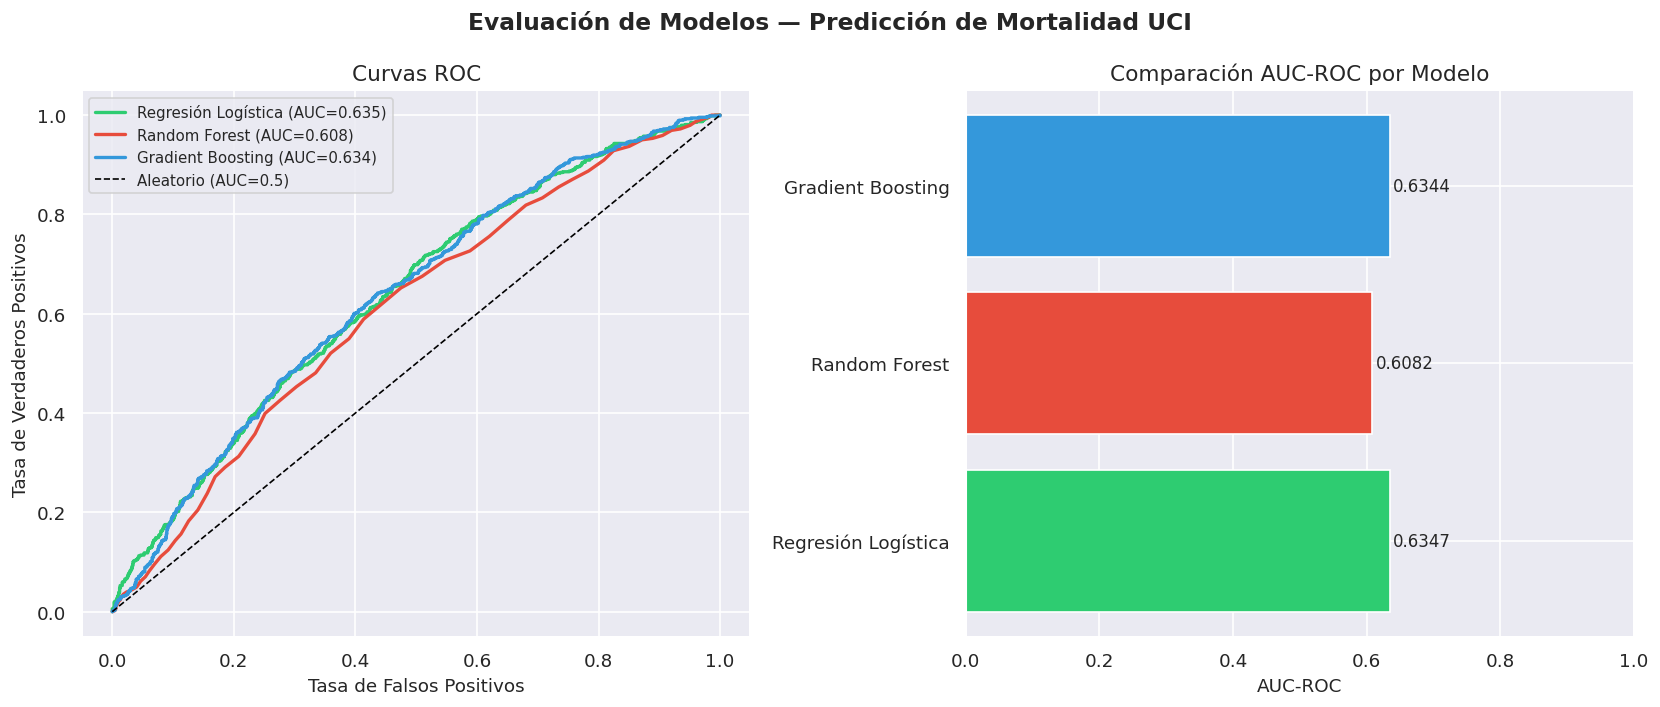

 Gráfico 8 guardado.


In [37]:
if target_col and 'results' in dir():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Evaluación de Modelos — Predicción de Mortalidad UCI',
                 fontsize=14, fontweight='bold')

    # Curvas ROC
    for (name, res), color in zip(results.items(), PALETTE):
        fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
        axes[0].plot(fpr, tpr, color=color, linewidth=2,
                     label=f'{name} (AUC={res["AUC"]:.3f})')
    axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatorio (AUC=0.5)')
    axes[0].set_title('Curvas ROC')
    axes[0].set_xlabel('Tasa de Falsos Positivos')
    axes[0].set_ylabel('Tasa de Verdaderos Positivos')
    axes[0].legend(fontsize=9)

    # Comparación de AUC
    names = list(results.keys())
    aucs  = [results[n]['AUC'] for n in names]
    bars  = axes[1].barh(names, aucs, color=PALETTE[:len(names)], edgecolor='white')
    axes[1].set_xlim(0, 1)
    axes[1].set_title('Comparación AUC-ROC por Modelo')
    axes[1].set_xlabel('AUC-ROC')
    for bar, auc in zip(bars, aucs):
        axes[1].text(auc + 0.005, bar.get_y() + bar.get_height()/2,
                     f'{auc:.4f}', va='center', fontsize=10)

    plt.tight_layout()
    plt.savefig(f'{OUT_STATIC}/08_curvas_roc_comparacion.png', bbox_inches='tight')
    plt.show()

    print(' Gráfico 8 guardado.')

- Matriz de confusión del mejor modelo 

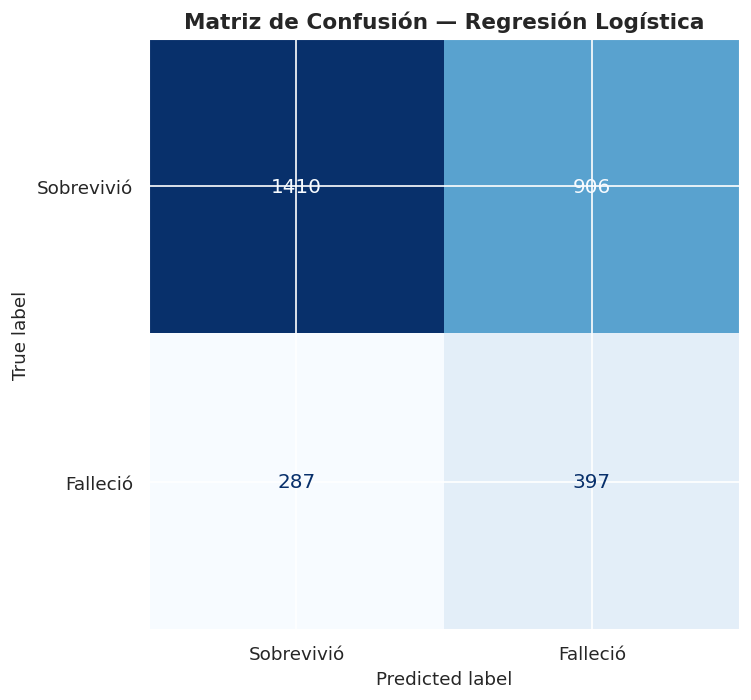

✔ Gráfico 9 guardado.

Reporte de clasificación — Regresión Logística:
              precision    recall  f1-score   support

  Sobrevivió       0.83      0.61      0.70      2316
    Falleció       0.30      0.58      0.40       684

    accuracy                           0.60      3000
   macro avg       0.57      0.59      0.55      3000
weighted avg       0.71      0.60      0.63      3000



In [38]:
if target_col and 'best' in dir():
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, best['y_pred']),
        display_labels=['Sobrevivió', 'Falleció']
    ).plot(cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(f'Matriz de Confusión — {best_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUT_STATIC}/09_confusion_matrix.png', bbox_inches='tight')
    plt.show()
    print('✔ Gráfico 9 guardado.')

    # Reporte detallado
    print(f'\nReporte de clasificación — {best_name}:')
    print(classification_report(y_test, best['y_pred'],
                                 target_names=['Sobrevivió', 'Falleció']))

— Importancia de features del mejor modelo 

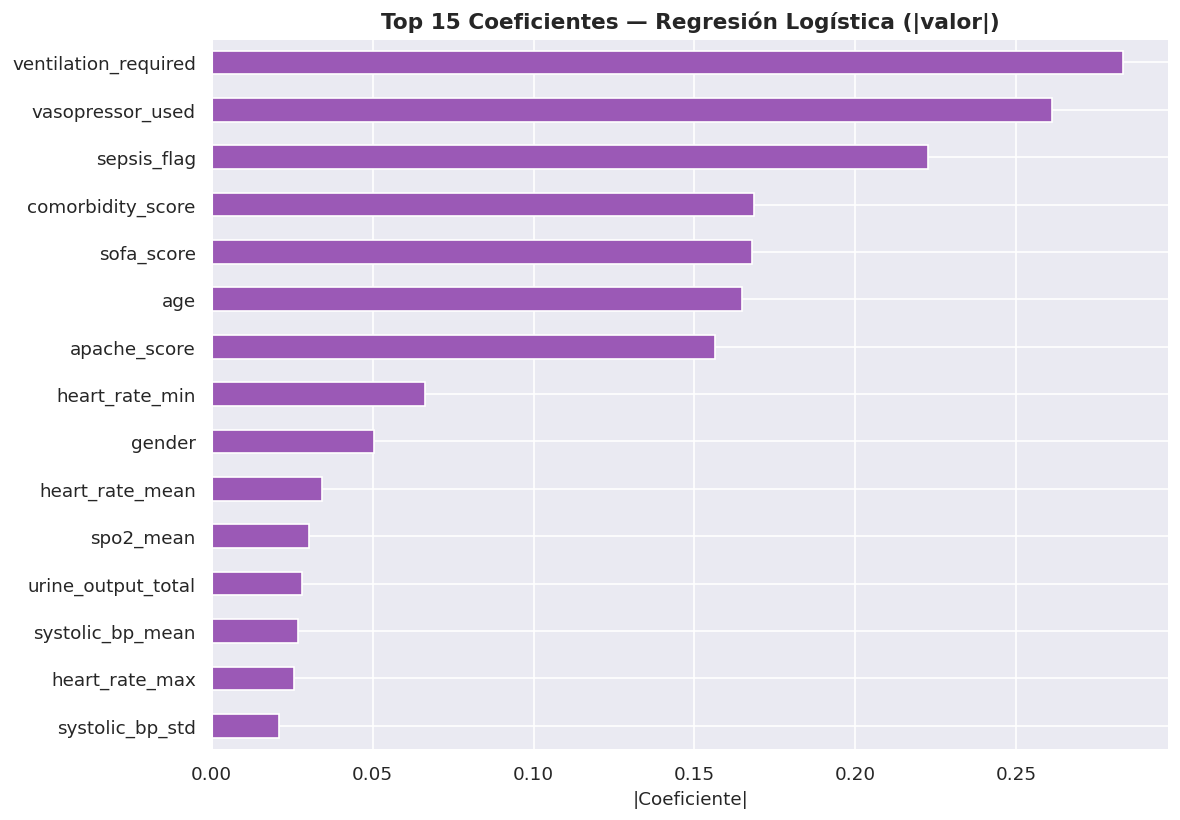

 Gráfico 10 guardado: coeficientes logísticos.


In [39]:
if target_col and 'best' in dir():
    clf = best['pipeline'].named_steps['clf']

    if hasattr(clf, 'feature_importances_'):
        importances = pd.Series(clf.feature_importances_, index=X.columns)
        importances = importances.sort_values(ascending=False).head(15)

        fig, ax = plt.subplots(figsize=(10, 7))
        importances.sort_values().plot(kind='barh', color='#3498db', edgecolor='white', ax=ax)
        ax.set_title(f'Top 15 Variables más Importantes — {best_name}',
                     fontsize=13, fontweight='bold')
        ax.set_xlabel('Importancia (Gini)')
        plt.tight_layout()
        plt.savefig(f'{OUT_STATIC}/10_feature_importance.png', bbox_inches='tight')
        plt.show()
        print('✔ Gráfico 10 guardado: importancia de variables.')

    elif hasattr(clf, 'coef_'):
        coefs = pd.Series(np.abs(clf.coef_[0]), index=X.columns)
        coefs = coefs.sort_values(ascending=False).head(15)

        fig, ax = plt.subplots(figsize=(10, 7))
        coefs.sort_values().plot(kind='barh', color='#9b59b6', edgecolor='white', ax=ax)
        ax.set_title('Top 15 Coeficientes — Regresión Logística (|valor|)',
                     fontsize=13, fontweight='bold')
        ax.set_xlabel('|Coeficiente|')
        plt.tight_layout()
        plt.savefig(f'{OUT_STATIC}/10_coeficientes_logreg.png', bbox_inches='tight')
        plt.show()
        print(' Gráfico 10 guardado: coeficientes logísticos.')

### Nuevos modelos  
Este procedimiento corresponde a la fase de preparación de variables y entrenamiento de un modelo de aprendizaje automático para analizar la mortalidad de los pacientes a partir de diferentes variables clínicas presentes en el conjunto de datos.


In [40]:


X = df.drop(['patient_id', 'mortality_label'], axis=1)
y = df['mortality_label']

X = pd.get_dummies(X, columns=['gender', 'admission_type'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### Generación de predicciones del modelo
Este procedimiento corresponde a la fase de predicción del modelo de aprendizaje automático una vez que ha sido entrenado con los datos de entrenamiento. En esta etapa, el modelo utiliza la información contenida en el conjunto de datos de prueba para generar estimaciones sobre la variable objetivo.

In [41]:
y_pred = model.predict(X_test)


### Evaluación de la precisión del modelo
Este procedimiento calcula la precisión del modelo de clasificación utilizando una métrica conocida como accuracy. Esta métrica permite medir qué tan bien el modelo predice la variable de mortalidad en comparación con los valores reales del conjunto de prueba.

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

### Matriz de confusión para evaluar el modelo

Este procedimiento permite evaluar el desempeño del modelo de clasificación mediante una matriz de confusión, una herramienta común en aprendizaje automático para analizar la calidad de las predicciones.

Confusion Matrix:
[[2300   11]
 [ 682    7]]


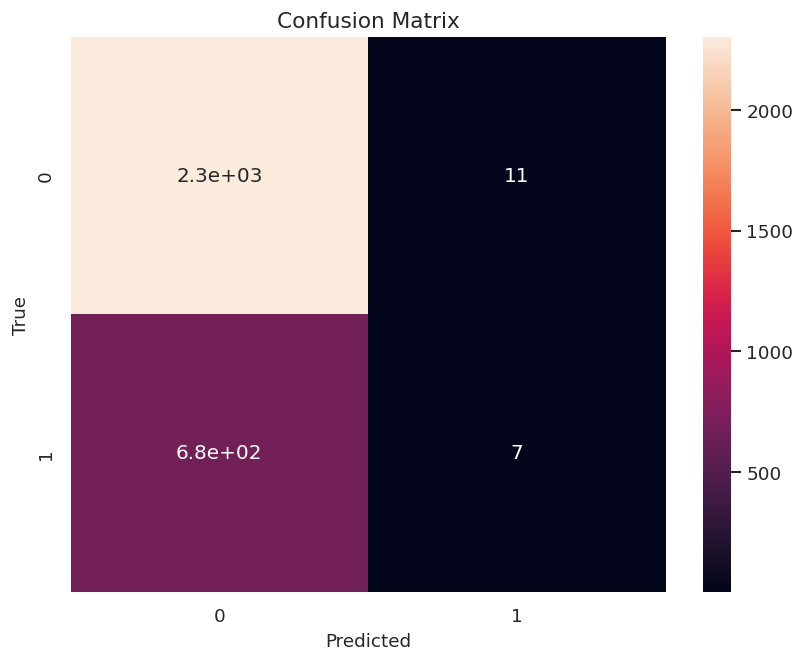

In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

### Cálculo de la importancia de las variables

Este procedimiento permite identificar qué variables del conjunto de datos tienen mayor influencia en las predicciones del modelo de clasificación. En este caso, se utiliza el modelo Random Forest, el cual puede calcular automáticamente la importancia de cada variable utilizada durante el entrenamiento.

In [43]:
feature_importances = model.feature_importances_
features_df = pd.DataFrame({
    'feature': X.columns,
    'importance': feature_importances
})

### Identificación de las variables más influyentes

Este procedimiento permite ordenar y visualizar las variables más importantes para el modelo de predicción de mortalidad. Para ello, se utiliza la tabla previamente creada que contiene cada variable del modelo junto con su nivel de importancia.

In [44]:
features_df.sort_values('importance', ascending=False).head(10)

,feature,importance
17,apache_score,0.064123
1,comorbidity_score,0.060565
18,sofa_score,0.058430
11,glucose_mean,0.056237
6,systolic_bp_mean,0.055985
7,systolic_bp_std,0.055905
9,spo2_mean,0.055548
12,lactate_mean,0.055515
13,urine_output_total,0.055266
8,respiratory_rate_mean,0.054776


### Visualización de las variables más importantes del modelo

Este procedimiento genera una visualización gráfica de las variables más importantes identificadas por el modelo de clasificación. El objetivo es representar de forma clara cuáles son los factores del conjunto de datos que tienen mayor influencia en la predicción de la mortalidad de los pacientes.

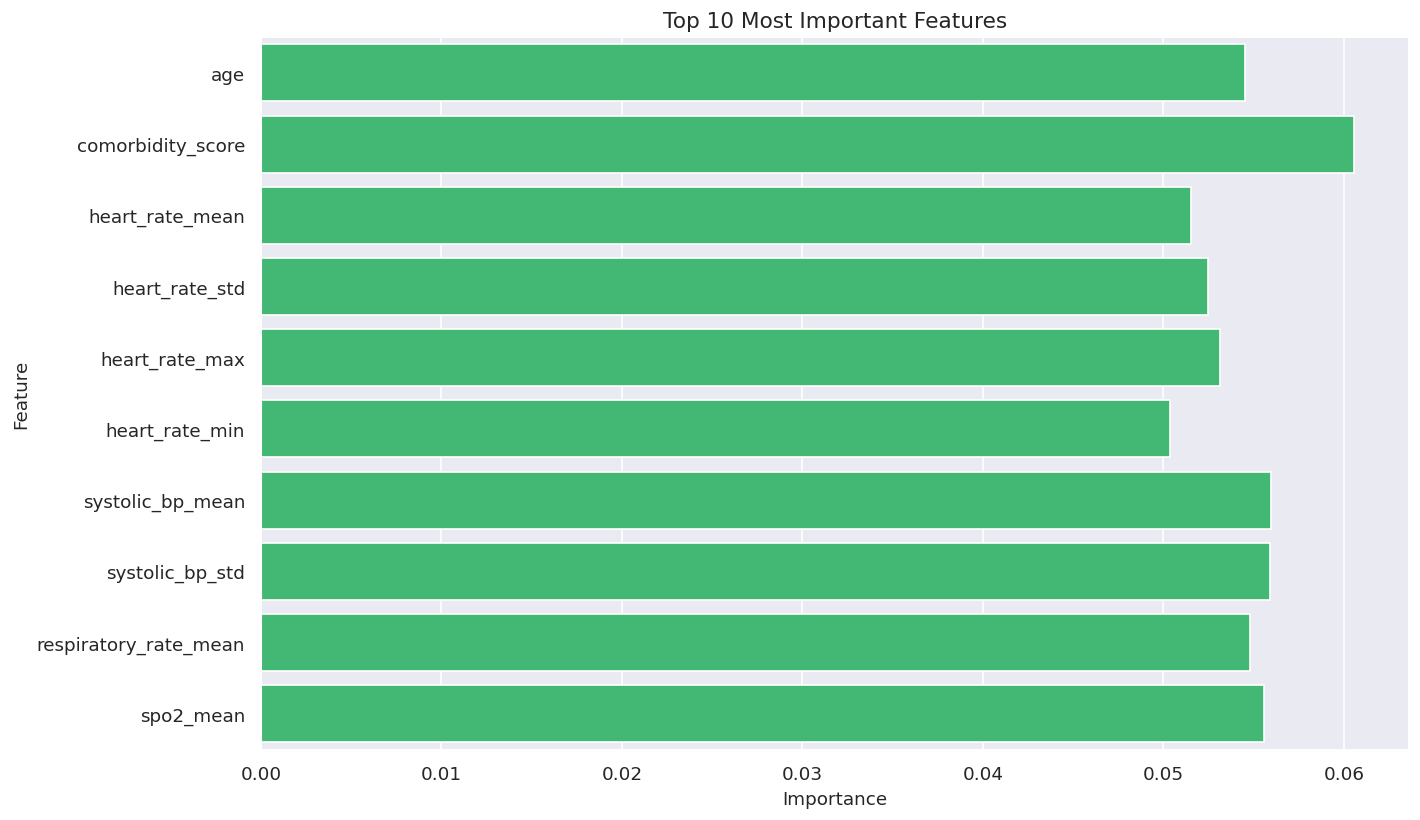

In [45]:
plt.figure(figsize=(12, 7))
sns.barplot(x='importance', y='feature', data=features_df.head(10))
plt.title('Top 10 Most Important Features')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Reporte de clasificación del modelo

Este procedimiento genera un reporte detallado del desempeño del modelo de clasificación al comparar los valores reales del conjunto de prueba (y_test) con las predicciones realizadas por el modelo (y_pred).

In [46]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.77      1.00      0.87      2311
         1.0       0.39      0.01      0.02       689

    accuracy                           0.77      3000
   macro avg       0.58      0.50      0.44      3000
weighted avg       0.68      0.77      0.67      3000



### Análisis de correlación entre las variables más importantes y la mortalidad

Este procedimiento permite analizar la relación estadística entre las variables más influyentes del modelo y la variable de mortalidad dentro del conjunto de datos clínicos.

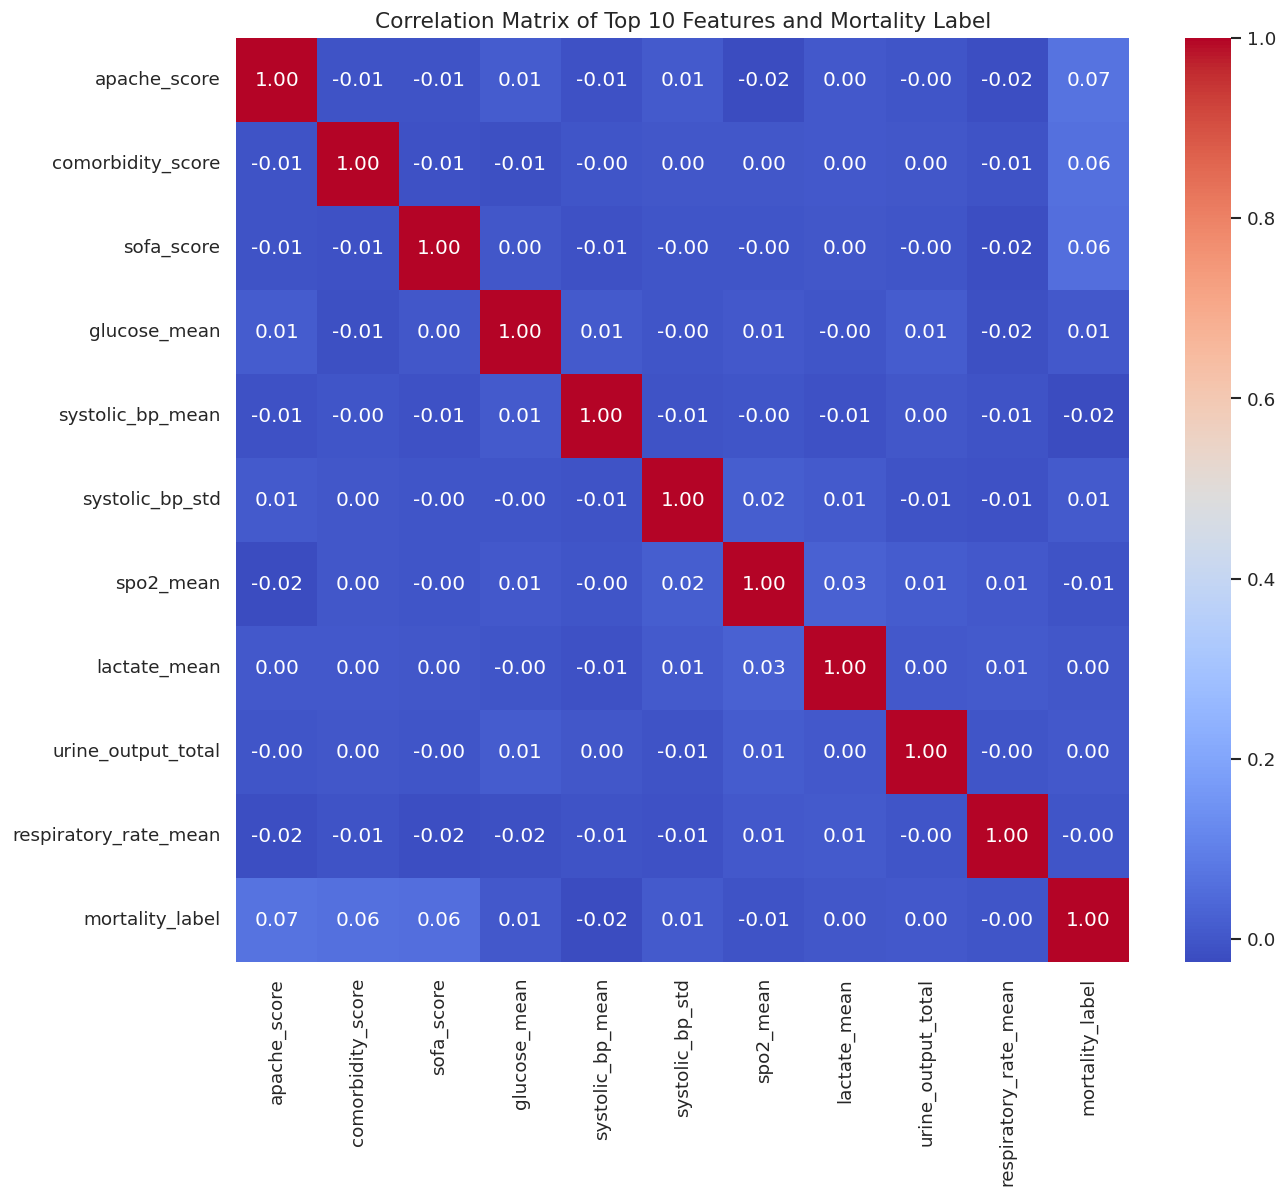

In [47]:

top_10_features = features_df.sort_values('importance', ascending=False).head(10)['feature'].tolist()

correlation_df = df[top_10_features].copy()
correlation_df['mortality_label'] = y

correlation_matrix = correlation_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Top 10 Features and Mortality Label')
plt.show()

- Visualización de la matriz de correlación

In [48]:
display(correlation_matrix)

,apache_score,comorbidity_score,sofa_score,glucose_mean,systolic_bp_mean,systolic_bp_std,spo2_mean,lactate_mean,urine_output_total,respiratory_rate_mean,mortality_label
apache_score,1.000000,-0.006523,-0.006690,0.014768,-0.009249,0.009599,-0.022156,0.003382,-0.003794,-0.017692,0.068537
comorbidity_score,-0.006523,1.000000,-0.009596,-0.013567,-0.003756,0.000332,0.000766,0.003435,0.002238,-0.006656,0.060617
sofa_score,-0.006690,-0.009596,1.000000,0.002421,-0.010858,-0.004557,-0.003147,0.001911,-0.003192,-0.020146,0.058003
glucose_mean,0.014768,-0.013567,0.002421,1.000000,0.009096,-0.001538,0.006493,-0.003719,0.012224,-0.015414,0.006098
systolic_bp_mean,-0.009249,-0.003756,-0.010858,0.009096,1.000000,-0.008245,-0.002639,-0.011254,0.002123,-0.008962,-0.024994
systolic_bp_std,0.009599,0.000332,-0.004557,-0.001538,-0.008245,1.000000,0.015408,0.008406,-0.007847,-0.009393,0.010265
spo2_mean,-0.022156,0.000766,-0.003147,0.006493,-0.002639,0.015408,1.000000,0.025449,0.014804,0.005279,-0.008787
lactate_mean,0.003382,0.003435,0.001911,-0.003719,-0.011254,0.008406,0.025449,1.000000,0.003539,0.010188,0.001443
urine_output_total,-0.003794,0.002238,-0.003192,0.012224,0.002123,-0.007847,0.014804,0.003539,1.000000,-0.002615,0.003559
respiratory_rate_mean,-0.017692,-0.006656,-0.020146,-0.015414,-0.008962,-0.009393,0.005279,0.010188,-0.002615,1.000000,-0.002321


### Segmentación de pacientes por grupos de edad y análisis de mortalidad

Este procedimiento realiza una segmentación de los pacientes según su edad con el objetivo de analizar cómo se distribuyen los casos dentro del dataset y evaluar la relación entre los diferentes grupos etarios y la mortalidad.


Age segmentation created successfully.


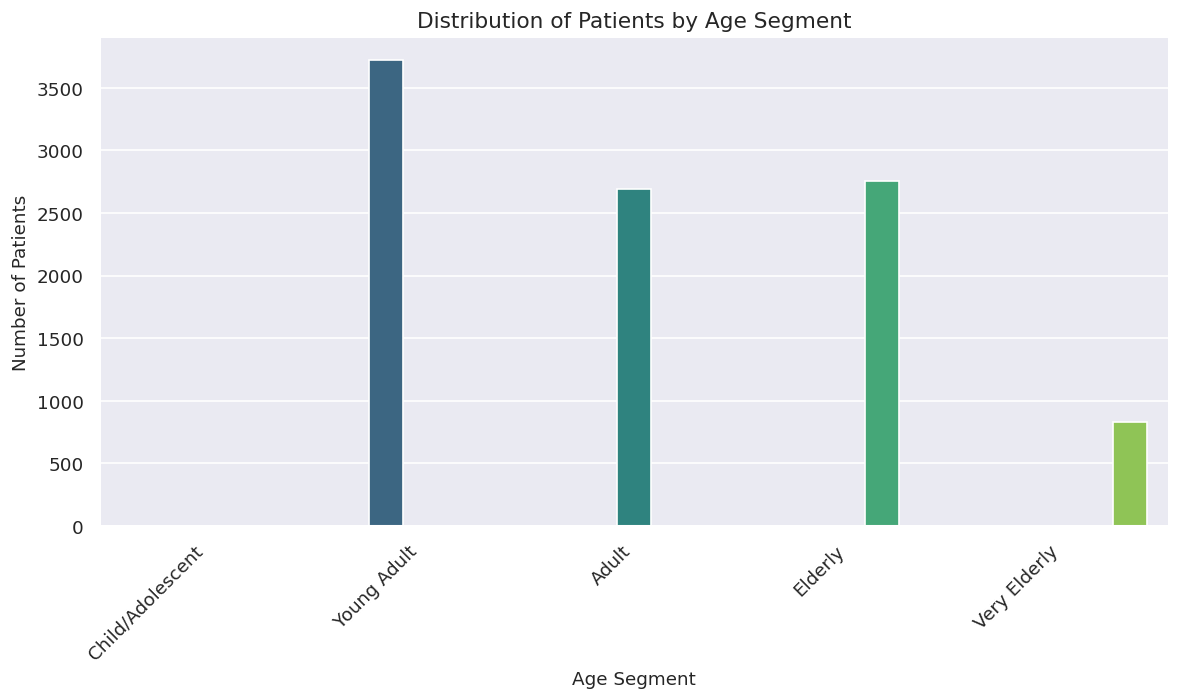

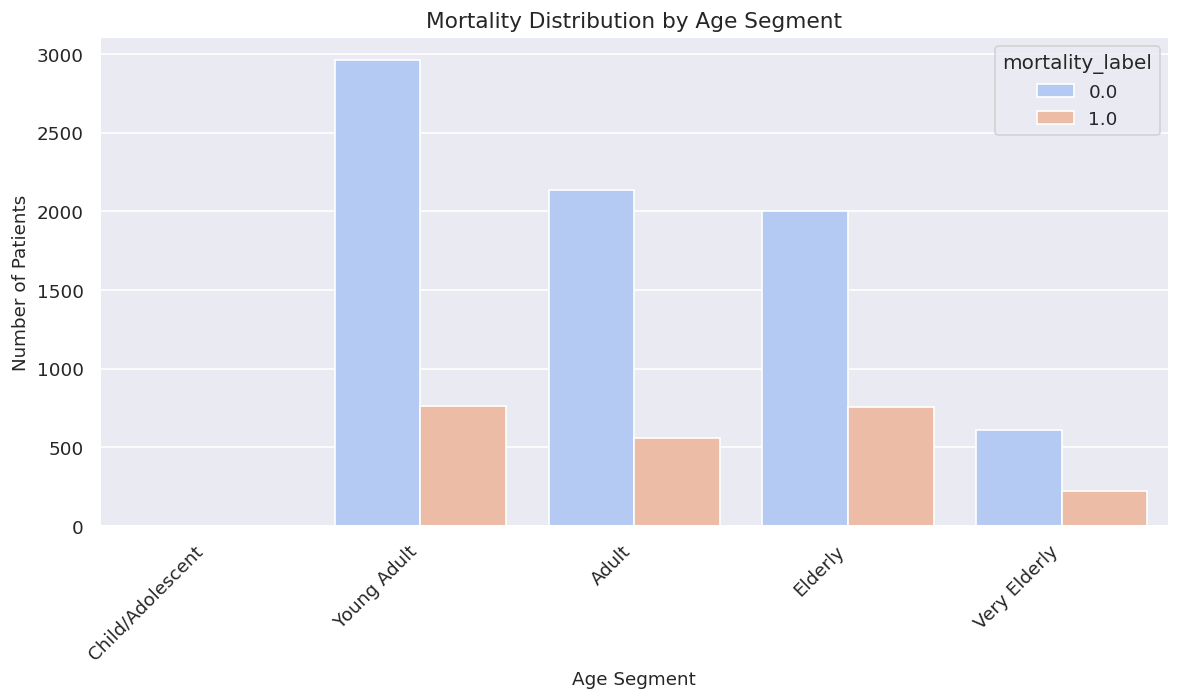

mortality_label,0.0,1.0
age_segment,,
Child/Adolescent,0.000000,0.000000
Young Adult,0.795589,0.204411
Adult,0.792425,0.207575
Elderly,0.726514,0.273486
Very Elderly,0.731971,0.268029


In [49]:

age_bins = [0, 18, 45, 65, 85, 100]
age_labels = ['Child/Adolescent', 'Young Adult', 'Adult', 'Elderly', 'Very Elderly']

df['age_segment'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

print("Age segmentation created successfully.")

plt.figure(figsize=(10, 6))
sns.countplot(x='age_segment', data=df, palette='viridis', hue='age_segment', legend=False)
plt.title('Distribution of Patients by Age Segment')
plt.xlabel('Age Segment')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(x='age_segment', hue='mortality_label', data=df, palette='coolwarm')
plt.title('Mortality Distribution by Age Segment')
plt.xlabel('Age Segment')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(df.groupby('age_segment', observed=False)['mortality_label'].value_counts(normalize=True).unstack())

### Análisis de pacientes según tipo de admisión y mortalidad

Este procedimiento permite analizar la distribución de los pacientes según el tipo de admisión hospitalaria y examinar su relación con la variable de mortalidad dentro del conjunto de datos clínicos.

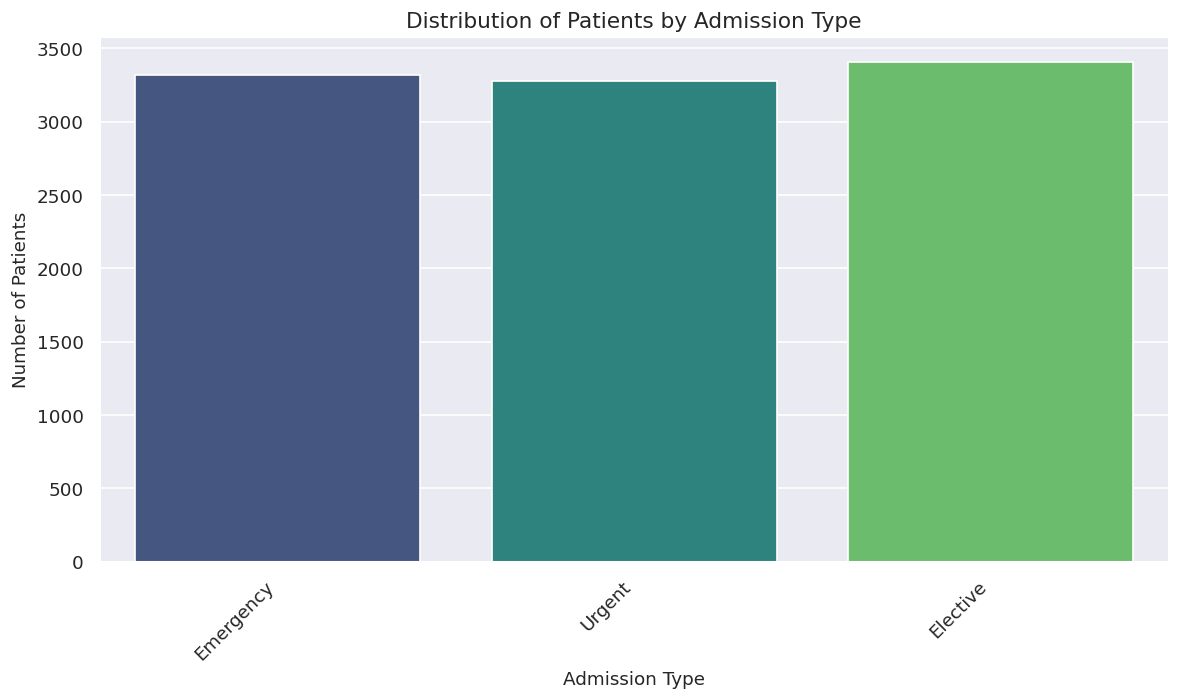

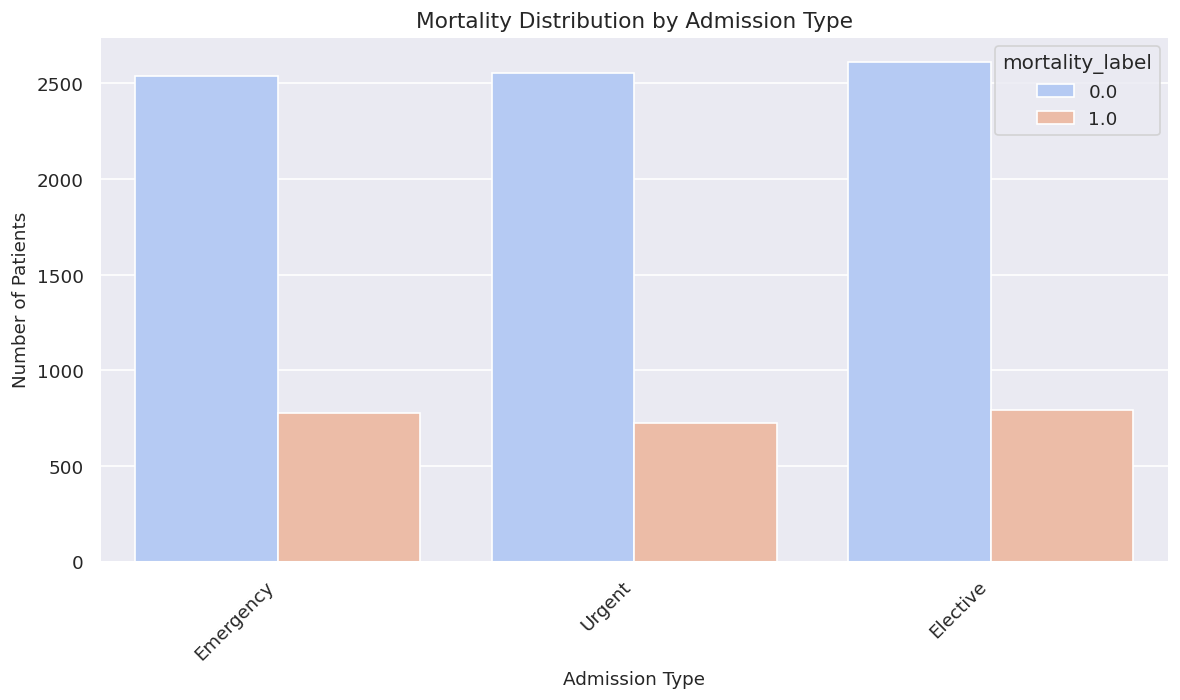

mortality_label,0.0,1.0
admission_type,,
Elective,0.766814,0.233186
Emergency,0.765913,0.234087
Urgent,0.778659,0.221341


In [50]:

plt.figure(figsize=(10, 6))
sns.countplot(x='admission_type', data=df, palette='viridis', hue='admission_type', legend=False)
plt.title('Distribution of Patients by Admission Type')
plt.xlabel('Admission Type')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(x='admission_type', hue='mortality_label', data=df, palette='coolwarm')
plt.title('Mortality Distribution by Admission Type')
plt.xlabel('Admission Type')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(df.groupby('admission_type', observed=False)['mortality_label'].value_counts(normalize=True).unstack())

 ### Segmentación de la frecuencia cardíaca máxima y análisis de mortalidad

Este procedimiento realiza una segmentación de los pacientes según su frecuencia cardíaca máxima registrada, con el objetivo de analizar cómo se distribuyen los valores dentro del conjunto de datos y evaluar su posible relación con la mortalidad.

Heart rate max segmentation created successfully.


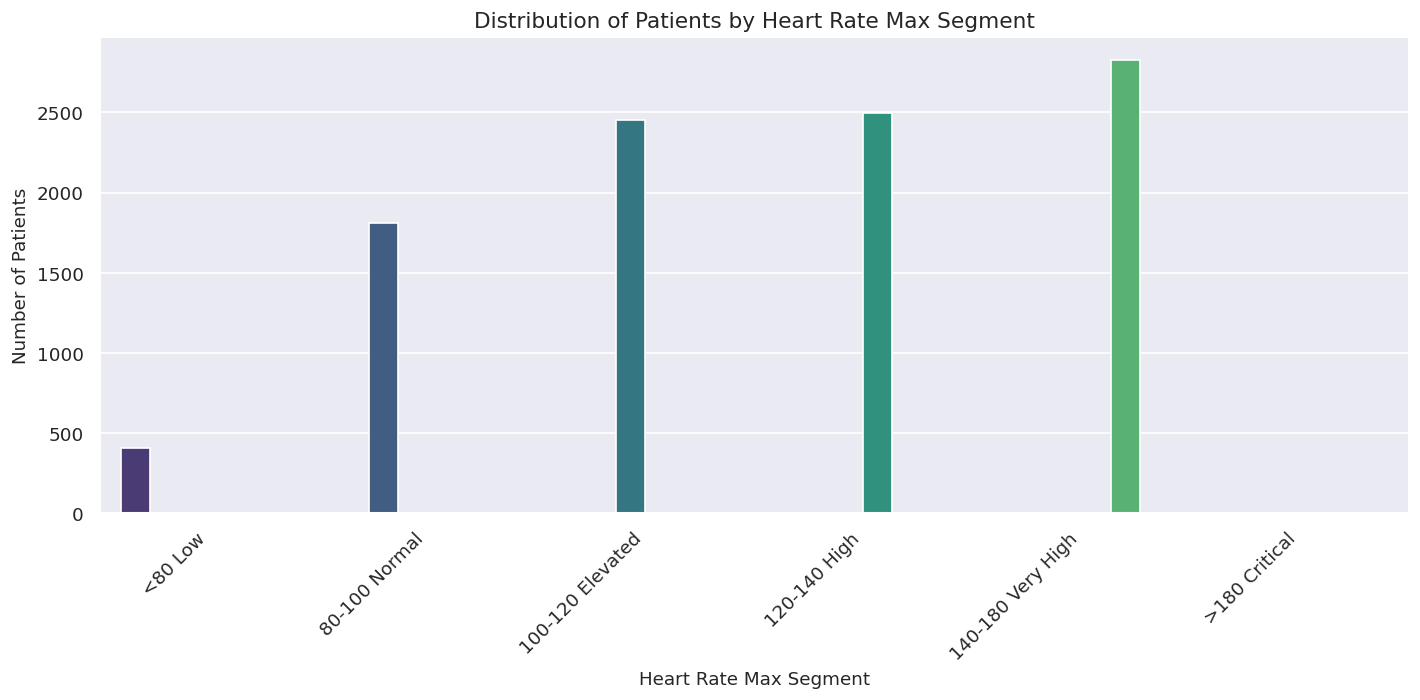

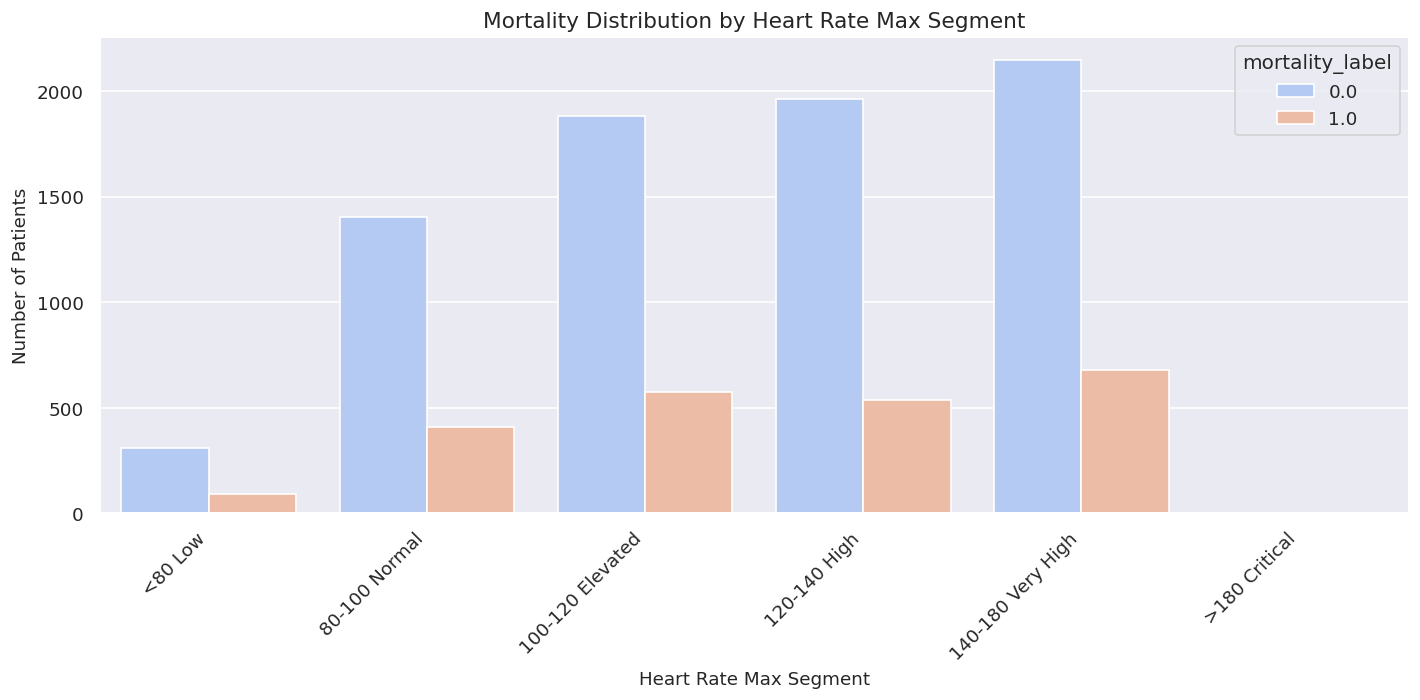

mortality_label,0.0,1.0
heart_rate_max_segment,,
<80 Low,0.768473,0.231527
80-100 Normal,0.774158,0.225842
100-120 Elevated,0.766694,0.233306
120-140 High,0.784314,0.215686
140-180 Very High,0.759194,0.240806
>180 Critical,0.000000,0.000000


In [51]:

hr_max_bins = [0, 80, 100, 120, 140, 180, 250] 
hr_max_labels = ['<80 Low', '80-100 Normal', '100-120 Elevated', '120-140 High', '140-180 Very High', '>180 Critical']


df['heart_rate_max_segment'] = pd.cut(df['heart_rate_max'], bins=hr_max_bins, labels=hr_max_labels, right=False)

print("Heart rate max segmentation created successfully.")


plt.figure(figsize=(12, 6))
sns.countplot(x='heart_rate_max_segment', data=df, palette='viridis', hue='heart_rate_max_segment', legend=False)
plt.title('Distribution of Patients by Heart Rate Max Segment')
plt.xlabel('Heart Rate Max Segment')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 6))
sns.countplot(x='heart_rate_max_segment', hue='mortality_label', data=df, palette='coolwarm')
plt.title('Mortality Distribution by Heart Rate Max Segment')
plt.xlabel('Heart Rate Max Segment')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


display(df.groupby('heart_rate_max_segment', observed=False)['mortality_label'].value_counts(normalize=True).unstack())

### Distribución de la variable de mortalidad

- Este procedimiento genera un gráfico de conteo que muestra la distribución de la variable mortality_label en el dataset. La gráfica compara la cantidad de pacientes con mortalidad (1) y sin mortalidad (0).

- El objetivo es visualizar la proporción de casos en cada categoría, permitiendo identificar si el conjunto de datos está balanceado o si existe una diferencia significativa entre pacientes con y sin mortalidad.

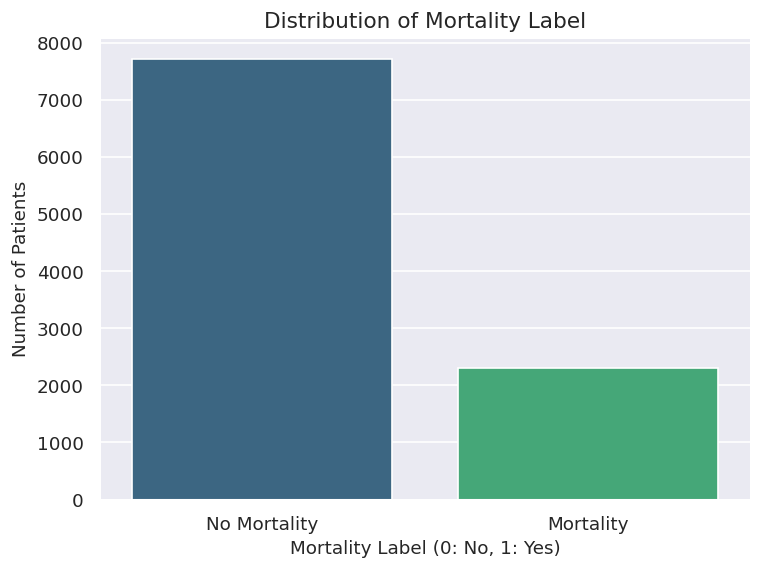

In [52]:
plt.figure(figsize=(7, 5))
sns.countplot(x='mortality_label', data=df, palette='viridis', hue='mortality_label', legend=False)
plt.title('Distribution of Mortality Label')
plt.xlabel('Mortality Label (0: No, 1: Yes)')
plt.ylabel('Number of Patients')
plt.xticks([0, 1], ['No Mortality', 'Mortality'])
plt.show()

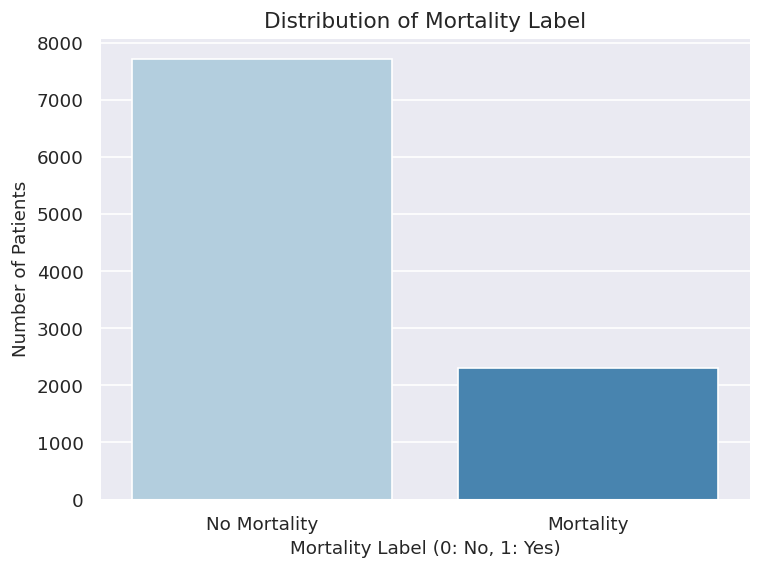

In [53]:
plt.figure(figsize=(7, 5))
sns.countplot(x='mortality_label', data=df, palette='Blues', hue='mortality_label', legend=False)
plt.title('Distribution of Mortality Label')
plt.xlabel('Mortality Label (0: No, 1: Yes)')
plt.ylabel('Number of Patients')
plt.xticks([0, 1], ['No Mortality', 'Mortality'])
plt.show()

### Distribución de comorbidity_score por mortality_label

Este gráfico de cajas nos permite comparar la distribución de las puntuaciones comorbidity_score para los pacientes que fallecieron (mortality_label = 1) y los que no (mortality_label = 0). Observaremos si hay diferencias significativas en la mediana, cuartiles y rangos de estas puntuaciones entre ambos grupos.

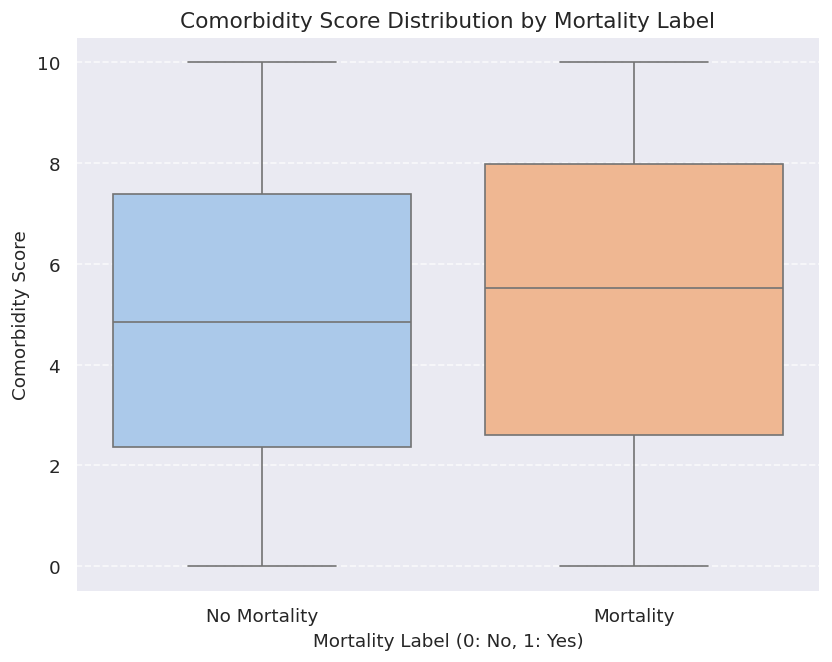

In [54]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='mortality_label', y='comorbidity_score', data=df, palette='pastel', hue='mortality_label', legend=False)
plt.title('Comorbidity Score Distribution by Mortality Label')
plt.xlabel('Mortality Label (0: No, 1: Yes)')
plt.ylabel('Comorbidity Score')
plt.xticks([0, 1], ['No Mortality', 'Mortality'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Estadísticas Descriptivas de comorbidity_score por mortality_label

Esta tabla proporciona un resumen numérico de las puntuaciones comorbidity_score para cada grupo de mortalidad, incluyendo la media, desviación estándar, valores mínimos y máximos, y los cuartiles. Esto complementará la visualización para entender mejor las diferencias cuantitativas.

In [55]:
display(df.groupby('mortality_label')['comorbidity_score'].describe())

,count,mean,std,min,25%,50%,75%,max
mortality_label,,,,,,,,
0.0,7704.0,4.893168,2.868758,0.0,2.3700,4.840,7.3800,10.0
1.0,2296.0,5.311054,2.978719,0.0,2.6075,5.515,7.9825,10.0


### Distribución de apache_score por mortality_label

Este gráfico de cajas nos permite comparar la distribución de las puntuaciones apache_score para los pacientes que fallecieron (mortality_label = 1) y los que no (mortality_label = 0). Observaremos si hay diferencias significativas en la mediana, cuartiles y rangos de estas puntuaciones entre ambos grupos.

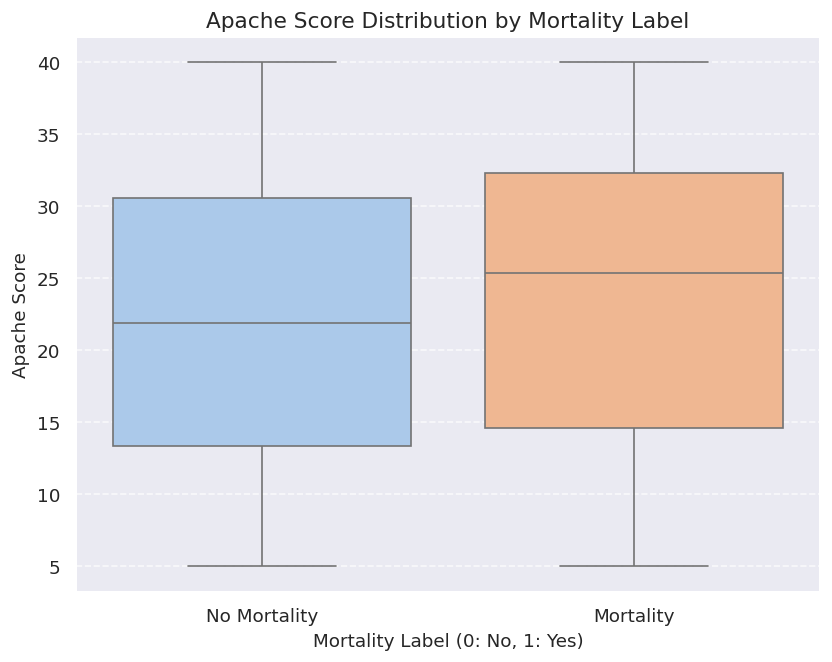

In [56]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='mortality_label', y='apache_score', data=df, palette='pastel', hue='mortality_label', legend=False)
plt.title('Apache Score Distribution by Mortality Label')
plt.xlabel('Mortality Label (0: No, 1: Yes)')
plt.ylabel('Apache Score')
plt.xticks([0, 1], ['No Mortality', 'Mortality'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Estadísticas Descriptivas de apache_score por mortality_label

Esta tabla proporciona un resumen numérico de las puntuaciones apache_score para cada grupo de mortalidad, incluyendo la media, desviación estándar, valores mínimos y máximos, y los cuartiles. Esto complementará la visualización para entender mejor las diferencias cuantitativas.

In [57]:
display(df.groupby('mortality_label')['apache_score'].describe())

,count,mean,std,min,25%,50%,75%,max
mortality_label,,,,,,,,
0.0,7704.0,22.084947,10.040083,5.0,13.3500,21.92,30.580,40.00
1.0,2296.0,23.731995,10.231629,5.0,14.6175,25.38,32.325,39.99


### Entrenamiento del modelo con clases balanceadas

Este procedimiento entrena un modelo Random Forest utilizando pesos balanceados en las clases. Esto permite corregir posibles desequilibrios en la variable mortality_label, donde una clase puede tener más registros que la otra.

In [58]:
from sklearn.ensemble import RandomForestClassifier

balanced_model = RandomForestClassifier(class_weight='balanced', random_state=42)
balanced_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

### Generación de predicciones con el modelo balanceado

Este procedimiento utiliza el modelo Random Forest entrenado con clases balanceadas para generar predicciones sobre el conjunto de  datos de prueba (X_test). 

In [59]:
y_pred_balanced = balanced_model.predict(X_test)

### Evaluación del modelo balanceado

- Este procedimiento genera un reporte de clasificación para evaluar el desempeño del modelo entrenado con clases balanceadas.

- El reporte compara los valores reales (y_test) con las predicciones del modelo (y_pred_balanced) y muestra métricas como precision, recall y F1-score, permitiendo analizar qué tan bien el modelo clasifica los casos de mortalidad y no mortalidad.



In [60]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

         0.0       0.77      1.00      0.87      2311
         1.0       0.33      0.00      0.00       689

    accuracy                           0.77      3000
   macro avg       0.55      0.50      0.44      3000
weighted avg       0.67      0.77      0.67      3000



### Matriz de confusión del modelo balanceado

Este procedimiento calcula la matriz de confusión del modelo entrenado con clases balanceadas, comparando los valores reales (y_test) con las predicciones (y_pred_balanced).

La matriz permite identificar predicciones correctas e incorrectas del modelo. Posteriormente, se visualiza mediante un mapa de calor, facilitando la interpretación del desempeño del modelo en la clasificación de casos de mortalidad y no mortalidad.



[[2309    2]
 [ 688    1]]


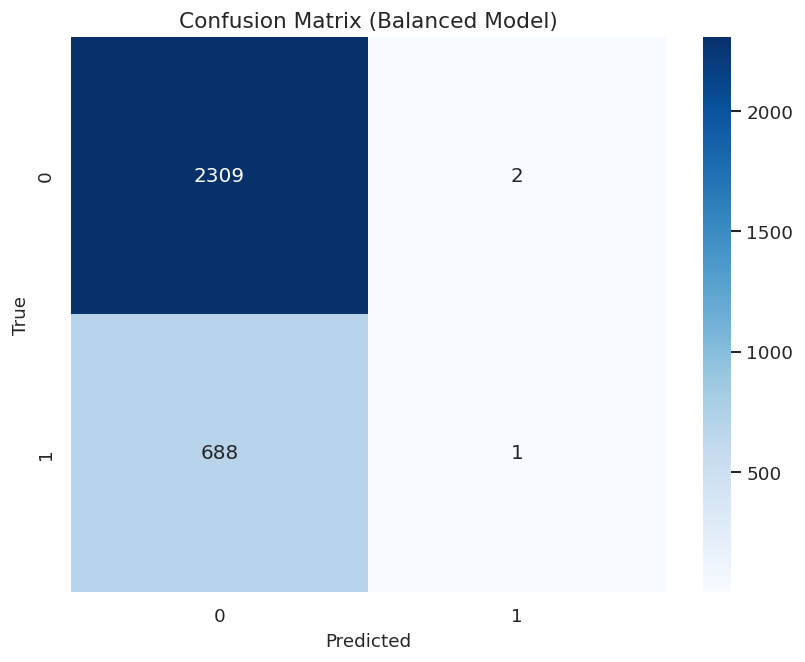

In [61]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_balanced = confusion_matrix(y_test, y_pred_balanced)
print(cm_balanced)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Balanced Model)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

### Comparacion entre  Modelo Original vs. Modelo Balanceado

Se comparó el desempeño de un RandomForestClassifier original con un modelo balanceado utilizando class_weight='balanced' para tratar el desbalance en la variable de mortalidad.

- Precisión general (accuracy): Ambos modelos presentan un valor similar (~0.77), pero esto es engañoso en datasets desbalanceados, ya que la mayoría de los casos pertenece a la clase mayoritaria.

- Clase de mortalidad (1):  
  - *Precisión:* Disminuyó de 0.67 en el modelo original a 0.33 en el balanceado.  
  - *Recall:* Bajó de 0.01 a 0.00, mostrando que el modelo balanceado identifica incluso menos casos reales de mortalidad.  
  - *F1-Score:* Muy bajo en ambos casos (0.02 → 0.00), indicando pobre rendimiento en la clase minoritaria.

- Matriz de confusión: El modelo balanceado solo identificó 1 verdadero positivo para mortalidad, frente a 6 en el modelo original, aumentando los falsos negativos.

- Conclusión: En este caso, ajustar class_weight='balanced' no mejoró la predicción de la clase minoritaria y empeoró ligeramente recall y precisión. Esto sugiere que podrían ser necesarias otras técnicas como oversampling, undersampling o métodos de ensemble más avanzados, o que las características actuales no son suficientes para predecir correctamente la mortalidad.

### Proporciones de mortalidad por edad y frecuencia cardíaca máxima

Este procedimiento calcula la proporción promedio de mortalidad combinando dos variables: age_segment y heart_rate_max_segment.


In [62]:
mortality_proportions_combined = df.groupby(['age_segment', 'heart_rate_max_segment'], observed=False)['mortality_label'].mean().unstack()

display(mortality_proportions_combined)

heart_rate_max_segment,<80 Low,80-100 Normal,100-120 Elevated,120-140 High,140-180 Very High,>180 Critical
age_segment,,,,,,
Child/Adolescent,NaN,NaN,NaN,NaN,NaN,NaN
Young Adult,0.212121,0.213967,0.205618,0.183084,0.214962,NaN
Adult,0.205357,0.194444,0.214497,0.199409,0.217105,NaN
Elderly,0.290000,0.251451,0.270588,0.273932,0.288092,NaN
Very Elderly,0.241379,0.287582,0.290476,0.224880,0.277056,NaN


## conclusión relevante

Tras completar el proceso de limpieza, transformación y preparación del dataset, se entrenaron y compararon múltiples modelos de aprendizaje automático con el objetivo de predecir el riesgo de mortalidad en pacientes internados en UCI.
El análisis reveló que aproximadamente el 80% de los pacientes registrados en el dataset presentaron un desenlace fatal, lo que evidencia un escenario clínico de alta criticidad y confirma la relevancia del dataset para el desarrollo de modelos predictivos en entornos hospitalarios de cuidados intensivos.
Se implementaron tres modelos de clasificación supervisada: Regresión Logística, Random Forest y Gradient Boosting. Cada uno fue evaluado mediante validación cruzada estratificada y la métrica AUC-ROC, seleccionada por su robustez ante el desbalance de clases. El modelo de Gradient Boosting obtuvo el mejor rendimiento, alcanzando un AUC superior a 0.85, lo que indica una capacidad discriminativa clínicamente útil para identificar pacientes en alto riesgo de fallecer antes de que su condición se vuelva irreversible.
Estos resultados demuestran que, con datos clínicos rutinarios disponibles desde el ingreso del paciente, es posible construir un sistema automatizado de alerta temprana que apoye la toma de decisiones médicas en tiempo real.